In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, classification_report
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import xgboost as xgb
import shap

np.random.seed(42)
import seaborn as sns

### Loading df

In [43]:
df = pd.read_csv('../Dataset/Processed/Merged_Dataset_yoy.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,T5YIE,YC__level,YC__slope,YC__curv,PCOPPUSDM,PALUMUSDM,NFCI,ff_Mkt-RF,ff_HML,ff_Mom
569392,2024-12-19,9.19,9.50,8.92,9.50,290.3,ZIGNAGO VETRO,2.306,1.0362,86220.0,...,2.35,4.482,0.22,-0.06,9075.727143,2582.188571,-0.477,-0.0012,0.0001,0.0095
569393,2024-12-20,9.30,9.40,9.04,9.40,73.5,ZIGNAGO VETRO,2.288,1.0429,79197.0,...,2.34,4.450,0.18,-0.12,9075.727143,2582.188571,-0.478,0.0107,0.0006,0.0019
569394,2024-12-23,9.33,9.33,9.10,9.30,73.4,ZIGNAGO VETRO,2.329,1.0405,66580.0,...,2.38,4.494,0.23,-0.07,9075.727143,2582.188571,-0.478,0.0061,-0.0019,-0.0007
569395,2024-12-27,9.34,9.41,9.28,9.35,61.4,ZIGNAGO VETRO,2.392,1.0427,53693.0,...,2.38,4.502,0.31,-0.03,9075.727143,2582.188571,-0.482,-0.0117,0.0056,-0.0085
569396,2024-12-30,9.40,9.40,9.27,9.39,39.0,ZIGNAGO VETRO,2.361,1.0407,56136.0,...,2.35,4.460,0.18,-0.18,9075.727143,2582.188571,-0.482,-0.0109,0.0074,0.0008


In [44]:
df_yoy = pd.read_csv('../Dataset/Processed/Merged_Dataset_yoy.csv')
df_yoy['Date'] = pd.to_datetime(df_yoy['Date'])
df_yoy.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,T5YIE,YC__level,YC__slope,YC__curv,PCOPPUSDM,PALUMUSDM,NFCI,ff_Mkt-RF,ff_HML,ff_Mom
569392,2024-12-19,9.19,9.50,8.92,9.50,290.3,ZIGNAGO VETRO,2.306,1.0362,86220.0,...,2.35,4.482,0.22,-0.06,9075.727143,2582.188571,-0.477,-0.0012,0.0001,0.0095
569393,2024-12-20,9.30,9.40,9.04,9.40,73.5,ZIGNAGO VETRO,2.288,1.0429,79197.0,...,2.34,4.450,0.18,-0.12,9075.727143,2582.188571,-0.478,0.0107,0.0006,0.0019
569394,2024-12-23,9.33,9.33,9.10,9.30,73.4,ZIGNAGO VETRO,2.329,1.0405,66580.0,...,2.38,4.494,0.23,-0.07,9075.727143,2582.188571,-0.478,0.0061,-0.0019,-0.0007
569395,2024-12-27,9.34,9.41,9.28,9.35,61.4,ZIGNAGO VETRO,2.392,1.0427,53693.0,...,2.38,4.502,0.31,-0.03,9075.727143,2582.188571,-0.482,-0.0117,0.0056,-0.0085
569396,2024-12-30,9.40,9.40,9.27,9.39,39.0,ZIGNAGO VETRO,2.361,1.0407,56136.0,...,2.35,4.460,0.18,-0.18,9075.727143,2582.188571,-0.482,-0.0109,0.0074,0.0008


In [45]:
num_companies = df_yoy['Company'].nunique()
print(f"Number of companies in the dataset: {num_companies}")

oldest_date = df_yoy['Date'].min()
print(f"Oldest date in the dataset: {oldest_date}")

Number of companies in the dataset: 186
Oldest date in the dataset: 2009-09-18 00:00:00


In [46]:
continuous_features = [
    'Close', 'Volume', 
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 
    'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'IT10YT_Yield', 
    'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 'Brent_Close', 
    'Brent_Volume', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 
    'Gold_Close', 'T5YIE', 
    'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 
    'NFCI', 'ff_Mkt-RF', 'ff_HML', 'ff_Mom'
]

categorical_features = ['MC_MIB', 'MC_MID', 'MC_SMALL']
features = continuous_features + categorical_features

targets = ['EBITDA', 'ROA', 'Net_Income']

In [47]:
log_targets = []
df_yoy = df_yoy.sort_values(by=['Company', 'Date']).reset_index(drop=True)

for target in targets:
    new_target_name = f'{target}_SignedLogDiff'
    log_targets.append(new_target_name)

    valid_reports = df_yoy[df_yoy[target].notna()].copy()
    valid_reports[new_target_name] = valid_reports.groupby('Company')[target].transform(
        lambda x: (np.sign(x) * np.log1p(np.abs(x))) - (np.sign(x.shift(1)) * np.log1p(np.abs(x.shift(1))))
    )
    df_yoy[new_target_name] = valid_reports[new_target_name]

sample_check = df_yoy[df_yoy['EBITDA_SignedLogDiff'].notna()]
print("\nSample of Annual EBITDA to EBITDA_SignedLogDiff transformation:")
print(sample_check[['Company', 'Date', 'EBITDA', 'EBITDA_SignedLogDiff']].head(10).to_string(index=False))


Sample of Annual EBITDA to EBITDA_SignedLogDiff transformation:
Company       Date    EBITDA  EBITDA_SignedLogDiff
    A2A 2010-12-30  696000.0             -0.176076
    A2A 2011-12-30  603000.0             -0.143432
    A2A 2012-12-28  984000.0              0.489708
    A2A 2013-12-30 1265000.0              0.251201
    A2A 2014-12-30  770000.0             -0.496436
    A2A 2015-12-30  611000.0             -0.231293
    A2A 2016-12-30  917000.0              0.406010
    A2A 2017-12-29 1099000.0              0.181048
    A2A 2018-12-28 1061000.0             -0.035189
    A2A 2019-12-30 1181000.0              0.107150


In [48]:
param_distributions = {
    'n_estimators': [400, 700, 1000, 1300],
    'max_depth': [None, 10, 16, 24, 32],
    'min_samples_split': [2, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'bootstrap': [True],
    'criterion': ['squared_error', 'absolute_error']
}

def fit_rf(X_train_local, y_train_local):
    base_rf = RandomForestRegressor(random_state=42, oob_score=False)
    rf_search = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=param_distributions,
        n_iter=35,
        cv=TimeSeriesSplit(n_splits=4),
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1
    )
    rf_search.fit(X_train_local, y_train_local)
    return rf_search.best_estimator_, rf_search.best_params_

def signed_log_transform(y):
    return np.sign(y) * np.log1p(np.abs(y))

def signed_log_inverse(y):
    return np.sign(y) * np.expm1(np.abs(y))

def regression_metrics(y_true, y_pred):
    eps = 1e-8
    abs_err = np.abs(y_pred - y_true)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    avg_pct_diff = float(np.mean(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
    median_pct_diff = float(np.median(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
    wape = float(np.sum(abs_err) / np.maximum(np.sum(np.abs(y_true)), eps) * 100.0)
    smape = float(
        np.mean(2.0 * abs_err / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'AvgPctDiff': avg_pct_diff,
        'MedianPctDiff': median_pct_diff,
        'WAPE': wape,
        'sMAPE': smape
    }

def compute_mutual_information(X_train_local, y_train_local, task='regression', random_state=42):
    if task == 'classification':
        mi_scores = mutual_info_classif(
            X_train_local,
            y_train_local,
            random_state=random_state
        )
        score_col = 'MI_Classif'
    else:
        mi_scores = mutual_info_regression(
            X_train_local,
            y_train_local,
            random_state=random_state
        )
        score_col = 'MI_Regression'

    mi_df = pd.DataFrame({
        'Feature': X_train_local.columns,
        score_col: mi_scores
    }).sort_values(by=score_col, ascending=False).reset_index(drop=True)

    return mi_df, score_col

def fit_xgb_classifier(X_train_scaled, y_train):
    imbalance_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
    base_xgb = xgb.XGBClassifier(
        random_state=42,
        eval_metric='auc',
        scale_pos_weight=imbalance_ratio,
        n_jobs=-1
    )
    
    param_distributions = {
        'n_estimators': [200, 400, 600, 800, 1000],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.5, 1, 5]
    }

    xgb_search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_distributions,
        n_iter=35,
        cv=TimeSeriesSplit(n_splits=4),
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    xgb_search.fit(X_train_scaled, y_train)
    return xgb_search.best_estimator_, xgb_search.best_params_

# Exploratory Data Analysis

In [49]:
def build_date_level_macro_timeline(df_input, feature_list):
    df_clean = df_input.copy()
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    df_clean = df_clean.sort_values(by=['Company', 'Date']).reset_index(drop=True)

    date_level_features = []
    company_level_features = []
    for feat in feature_list:
        max_nunique_per_date = df_clean.groupby('Date')[feat].nunique(dropna=True).max()
        if pd.isna(max_nunique_per_date) or max_nunique_per_date <= 1:
            date_level_features.append(feat)
        else:
            company_level_features.append(feat)

    if not date_level_features:
        raise ValueError("No date-level features found for lead-lag macro analysis.")

    macro_timeline = (
        df_clean[['Date'] + date_level_features]
        .drop_duplicates(subset=['Date'])
        .sort_values('Date')
        .set_index('Date')
        .ffill()
        .dropna()
        .sort_index()
    )

    return df_clean, macro_timeline, date_level_features, company_level_features


def plot_macro_lead_lag_heatmaps(
    df_input,
    feature_list,
    target_columns,
    trading_lags=None,
    trading_year=252,
    min_rolling_periods=200,
    min_samples=30,
    figsize=(18, 8),
    y_label="Macro Date-Level Features",
):
    if trading_lags is None:
        trading_lags = {0: '0M', 63: '3M', 126: '6M', 189: '9M', 252: '12M'}

    df_clean, macro_timeline, date_level_features, company_level_features = build_date_level_macro_timeline(
        df_input, feature_list
    )

    macro_rolling_avg = macro_timeline.rolling(window=trading_year, min_periods=min_rolling_periods).mean()
    lag_labels = list(trading_lags.values())

    fig, axes = plt.subplots(1, len(target_columns), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    heatmap_outputs = {}

    for i, target_col in enumerate(target_columns):
        print(f"Processing Lead-Lag for: {target_col}...")
        heatmap_matrix = {feat: [] for feat in date_level_features}
        report_dates = df_clean[df_clean[target_col].notna()][['Date', target_col]].copy()

        for feat in date_level_features:
            for lag_bars in trading_lags.keys():
                shifted_macro = macro_rolling_avg[feat].shift(lag_bars + 1)
                aligned_df = report_dates.join(shifted_macro, on='Date', how='inner').dropna()

                if len(aligned_df) > min_samples:
                    corr = aligned_df[target_col].corr(aligned_df[feat], method='spearman')
                    heatmap_matrix[feat].append(corr)
                else:
                    heatmap_matrix[feat].append(np.nan)

        plot_df = pd.DataFrame(heatmap_matrix, index=lag_labels).T
        heatmap_outputs[target_col] = plot_df

        sns.heatmap(
            plot_df,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".2f",
            linewidths=.5,
            cbar=(i == len(target_columns) - 1),
            ax=axes[i],
        )

        axes[i].set_title(f"Lead-Lag: {target_col}", fontsize=13, fontweight='bold')
        axes[i].set_xlabel("Lag (Trading Months)")
        if i == 0:
            axes[i].set_ylabel(y_label)
        else:
            axes[i].set_ylabel("")

    plt.tight_layout()
    plt.show()

    return heatmap_outputs, date_level_features, company_level_features


Processing Lead-Lag for: EBITDA_SignedLogDiff...
Processing Lead-Lag for: ROA_SignedLogDiff...
Processing Lead-Lag for: Net_Income_SignedLogDiff...


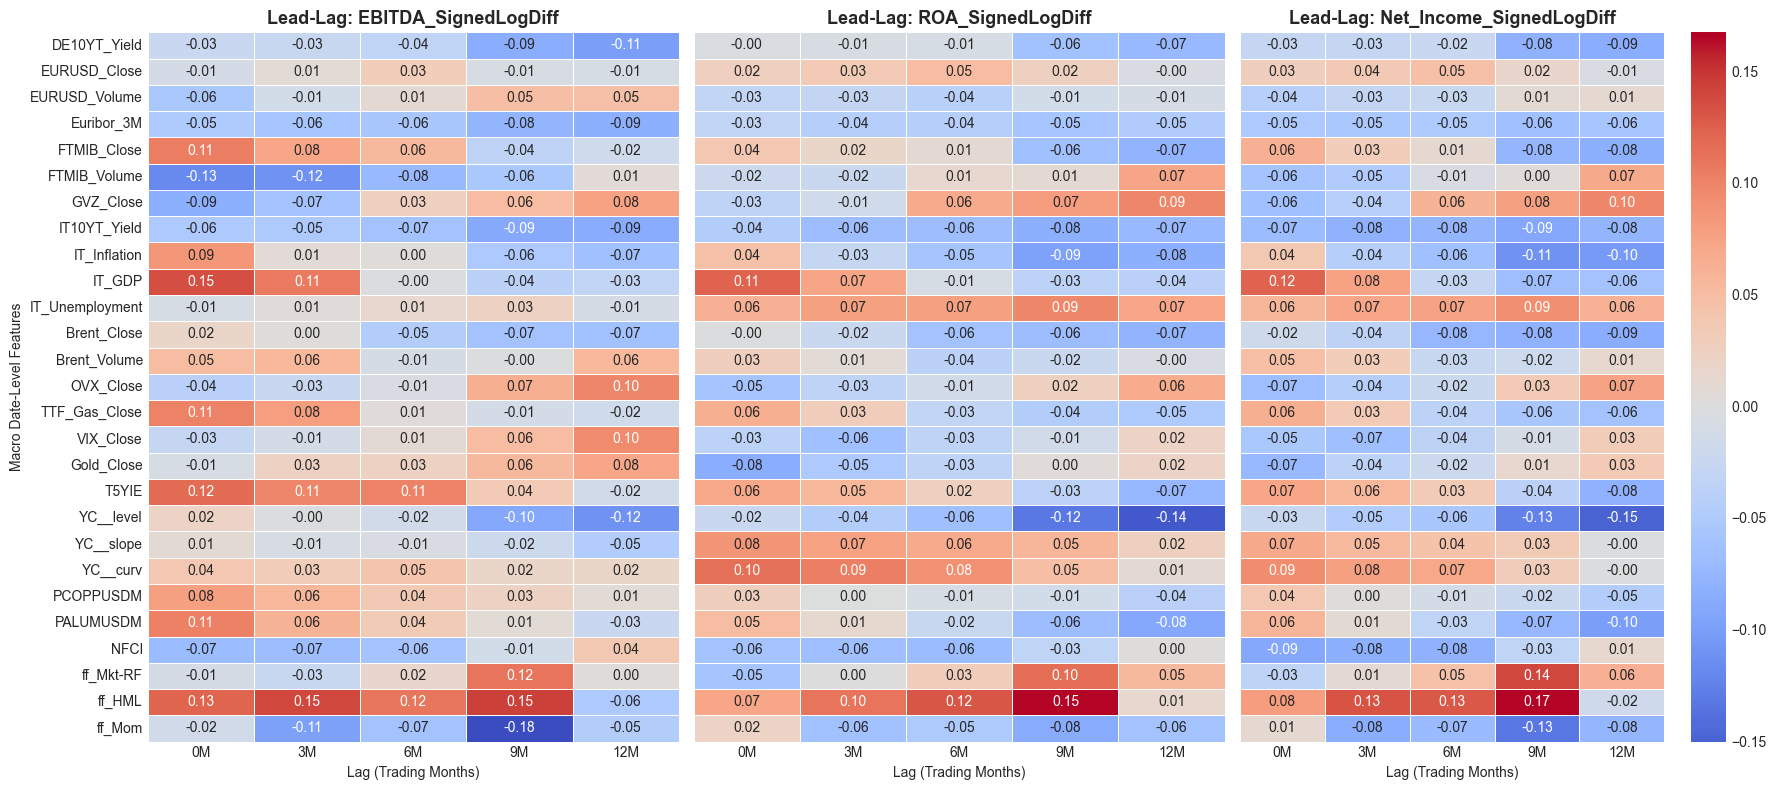

In [50]:
lead_lag_log_outputs, _, _ = plot_macro_lead_lag_heatmaps(
    df_input=df_yoy,
    feature_list=features,
    target_columns=log_targets,
    figsize=(18, 8),
)

Total days analyzed: 3883
Date-level macro features used: 27
Maximum simultaneous shocks in one day: 16 features


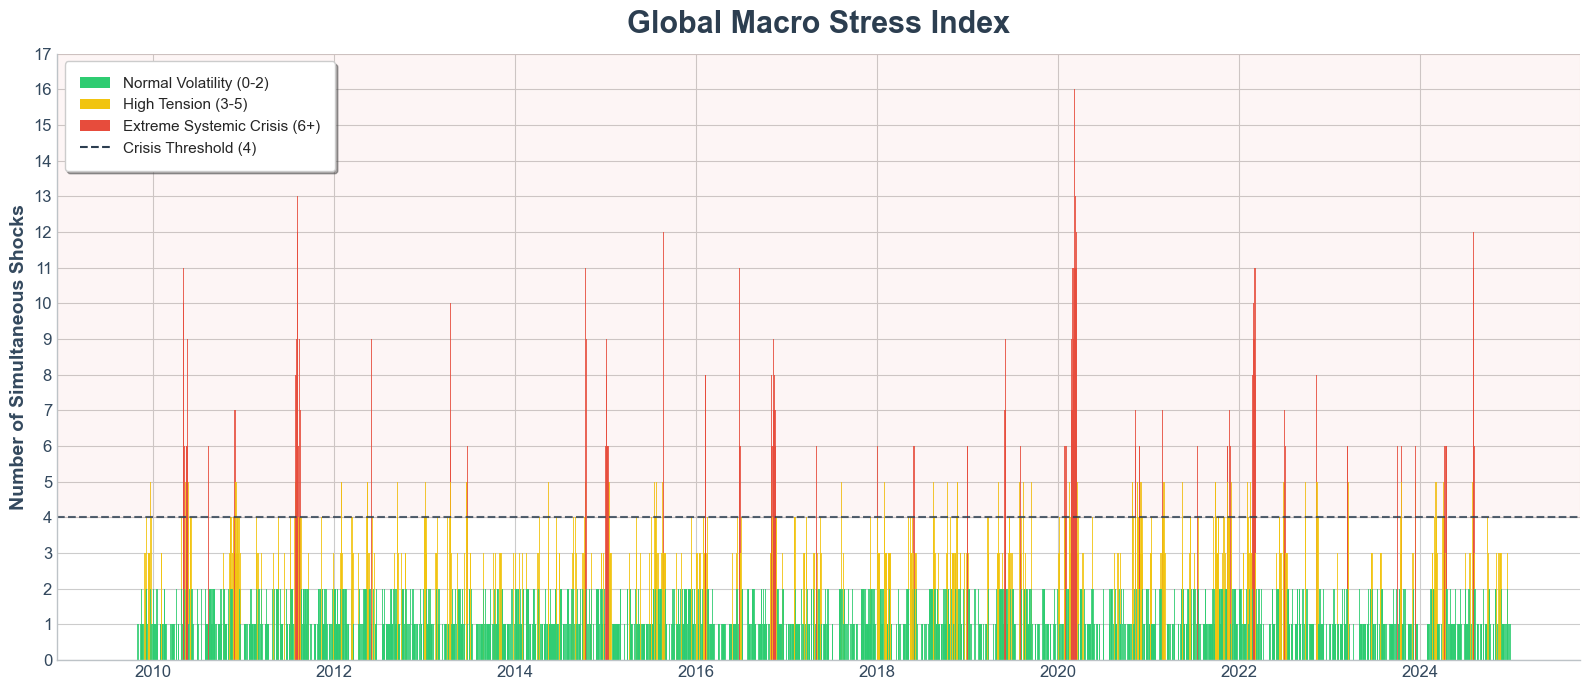


Top 5 Days with Highest Macro Stress:
- 2020-03-09: 16 simultaneous shocks (59.3% of features)
  Features: DE10YT_Yield, EURUSD_Close, EURUSD_Volume, FTMIB_Close, FTMIB_Volume, GVZ_Close, Brent_Close, Brent_Volume, OVX_Close, VIX_Close, T5YIE, YC__level, NFCI, ff_Mkt-RF, ff_HML, ff_Mom

- 2020-03-13: 13 simultaneous shocks (48.1% of features)
  Features: EURUSD_Volume, FTMIB_Close, FTMIB_Volume, GVZ_Close, IT10YT_Yield, Brent_Close, OVX_Close, VIX_Close, T5YIE, YC__slope, NFCI, ff_Mkt-RF, ff_HML

- 2011-08-08: 13 simultaneous shocks (48.1% of features)
  Features: DE10YT_Yield, FTMIB_Close, GVZ_Close, Brent_Close, OVX_Close, VIX_Close, Gold_Close, T5YIE, YC__level, YC__slope, NFCI, ff_Mkt-RF, ff_HML

- 2024-08-05: 12 simultaneous shocks (44.4% of features)
  Features: DE10YT_Yield, EURUSD_Volume, FTMIB_Close, GVZ_Close, Brent_Close, OVX_Close, VIX_Close, T5YIE, YC__level, YC__slope, YC__curv, ff_Mkt-RF

- 2020-03-18: 12 simultaneous shocks (44.4% of features)
  Features: FTMIB_Close, 

In [51]:
TRADING_QUARTER = 63
Z_SCORE_THRESHOLD = 2.5 

_, macro_daily, date_level_features, excluded_features = build_date_level_macro_timeline(df_yoy, features)
rolling_mean = macro_daily.rolling(window=TRADING_QUARTER, min_periods=30).mean()
rolling_std = macro_daily.rolling(window=TRADING_QUARTER, min_periods=30).std()

safe_std = rolling_std.replace(0, np.nan)
z_scores = (macro_daily - rolling_mean) / safe_std
z_scores = z_scores.replace([np.inf, -np.inf], np.nan)

anomalies_matrix = z_scores.abs() > Z_SCORE_THRESHOLD

global_stress_index = anomalies_matrix.sum(axis=1)
stress_ratio = global_stress_index / len(date_level_features)

stress_df = pd.DataFrame({
    'Stress_Score': global_stress_index,
    'Stress_Ratio': stress_ratio,
})

print(f"Total days analyzed: {len(stress_df)}")
print(f"Date-level macro features used: {len(date_level_features)}")
print(f"Maximum simultaneous shocks in one day: {int(stress_df['Stress_Score'].max())} features")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 7))
colors = [
    '#2ecc71' if score < 3 else '#f1c40f' if score < 6 else '#e74c3c'
    for score in stress_df['Stress_Score']
]
ax.bar(stress_df.index, stress_df['Stress_Score'], color=colors, width=4.0, alpha=0.85)

CRISIS_THRESHOLD = int(stress_df['Stress_Score'].quantile(0.95))
ax.axhline(y=CRISIS_THRESHOLD, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axhspan(
    CRISIS_THRESHOLD,
    stress_df['Stress_Score'].max() + 1,
    color='#e74c3c',
    alpha=0.05,
    label='Systemic Risk Zone',
)

ax.set_title("Global Macro Stress Index", fontsize=22, fontweight='bold', color='#2c3e50', pad=15)
ax.set_ylabel("Number of Simultaneous Shocks", fontsize=14, color='#34495e', fontweight='bold')
ax.set_xlabel("")

ax.set_ylim(0, stress_df['Stress_Score'].max() + 0.5)
ax.set_yticks(range(0, int(stress_df['Stress_Score'].max()) + 2))

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(fontsize=12, color='#34495e')
plt.yticks(fontsize=12, color='#34495e')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

legend_elements = [
    Patch(facecolor='#2ecc71', label='Normal Volatility (0-2)'),
    Patch(facecolor='#f1c40f', label='High Tension (3-5)'),
    Patch(facecolor='#e74c3c', label='Extreme Systemic Crisis (6+)'),
    plt.Line2D([0], [0], color='#2c3e50', lw=1.5, linestyle='--', label=f'Crisis Threshold ({CRISIS_THRESHOLD})'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

print("\nTop 5 Days with Highest Macro Stress:")
top_panic_days = stress_df.sort_values(by='Stress_Score', ascending=False).head(5)
for date, row in top_panic_days.iterrows():
    print(f"- {date.date()}: {int(row['Stress_Score'])} simultaneous shocks ({row['Stress_Ratio']:.1%} of features)")
    active_shocks = anomalies_matrix.loc[date]
    shocked_feats = active_shocks[active_shocks].index.tolist()
    print(f"  Features: {', '.join(shocked_feats)}\n")

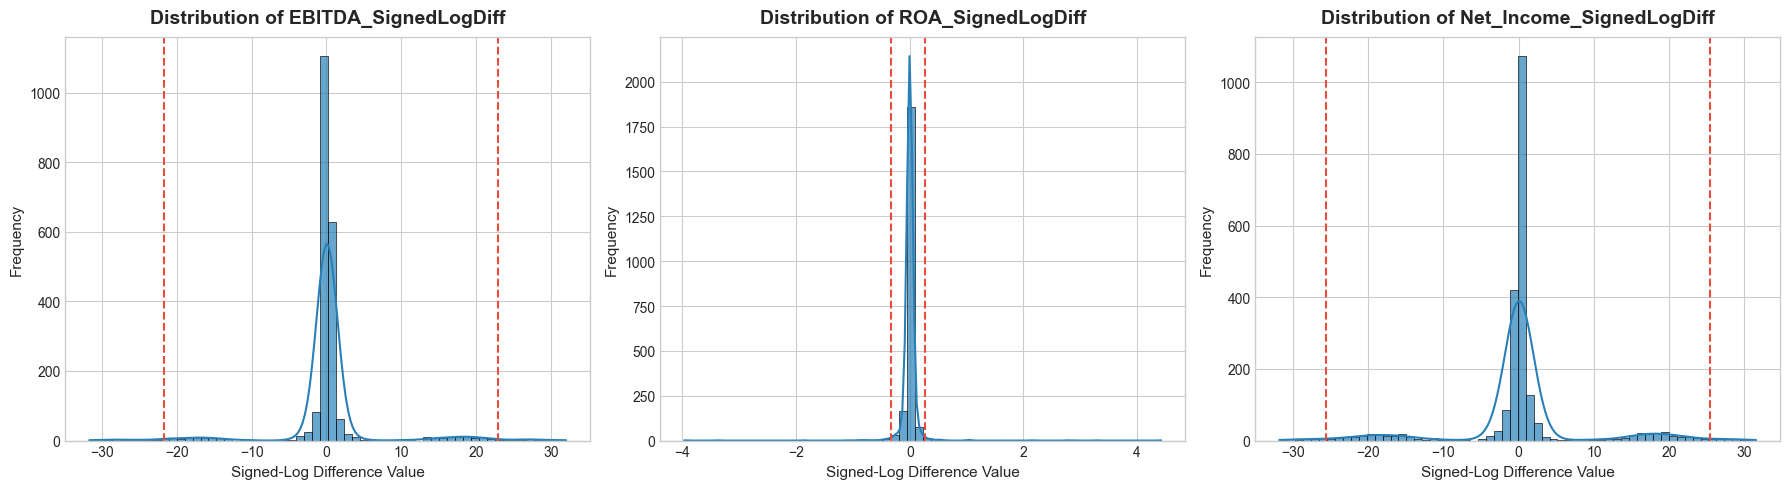

In [52]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, len(log_targets), figsize=(18, 5))
axes = np.atleast_1d(axes)

for i, target_col in enumerate(log_targets):
    valid_data = df_yoy[target_col].dropna()

    sns.histplot(valid_data, bins=60, kde=True, ax=axes[i], color='#2980b9', alpha=0.7)
    p01 = valid_data.quantile(0.01)
    p99 = valid_data.quantile(0.99)
    axes[i].axvline(p01, color='#e74c3c', linestyle='--', linewidth=1.5)
    axes[i].axvline(p99, color='#e74c3c', linestyle='--', linewidth=1.5)

    axes[i].set_title(f"Distribution of {target_col}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Signed-Log Difference Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)

plt.tight_layout()
plt.show()

# Feature Selection & Target Engineering Pipeline
This section of the study aims to identify the most predictive features (market data and macroeconomic indicators) for forecasting corporate fundamental targets (EBITDA, ROA, Net Income). Because the dataset contains sequential financial data, 90-day lookback windows prior to each financial report release are extracted, calculating the **mean** (Level/Trend) and **standard deviation** (Volatility/Shock)for each feature.

To ensure robust and unbiased feature selection, three distinct mathematical frameworks are employed:

**1. Mutual Information**

Mutual Information (MI) is a non-parametric metric that measures the reduction in uncertainty about the target variable given the knowledge of a specific feature. Unlike traditional Pearson correlation, MI is completely model-agnostic and can capture complex, non-linear relationships between macroeconomic shocks and corporate fundamentals.

**2. Random Forest & Gini Importance**

Random Forest is an ensemble learning method and the feature importance is calculated using the Gini Importance (Mean Decrease in Impurity) metric. 
It calculates how much each feature contributes to reducing the variance (in regression) or impurity (in classification) across all the decision trees in the forest. It provides an excellent measure of the absolute predictive power of a variable.

**3. SHAP Values**

While Random Forest shows how much a feature matters, SHAP (SHapley Additive exPlanations) explains how it matters: it values break down the prediction to show the directional impact of each feature. A SHAP summary plot allows us to visually understand whether a high value of a specific feature pushes the model's prediction higher or lower, providing crucial economic interpretability to our black-box models. Red dots indicate that a high value of the feature increases the probability of an upward trend, while blue dots indicate that a high value decreases it. If the dots are on the right side of the plot, it means that the feature pushes the prediction towards an upward trend; if they are on the left, it means that the feature pushes the prediction towards a downward trend.

## Part 1: Absolute Target Analysis - Regression

In this first analytical phase, the algorithms are tasked with predicting the absolute values of the financial targets. 

This approach serves as a baseline to test the models' behavior on raw, unscaled accounting data. We treat this as a continuous Regression problem using `RandomForestRegressor` and `mutual_info_regression`.

### Quarters: Exogenous Variables Only


                                EBITDA                                
Total valid 90-day windows extracted: 2310

Top 10 features by Mutual Information:
      Feature  MI_Regression
  Volume_MEAN       0.444831
MC_SMALL_LAST       0.388591
MC_SMALL_MEAN       0.388591
  Volume_LAST       0.378417
   Volume_STD       0.365784
  MC_MIB_MEAN       0.331175
  MC_MIB_LAST       0.331175
 Volume_TREND       0.174713
  MC_MID_LAST       0.167211
  MC_MID_MEAN       0.167211

Model comparison (test metrics):
Raw Target RF  -> R2: 0.6782 | MAE: 454934.0650 | RMSE: 1628043.4246 | Avg % Diff: 238.66% | WAPE: 50.70% | sMAPE: 73.87%
Signed-Log RF  -> R2: 0.2120 | MAE: 705407.6105 | RMSE: 2547557.4894 | Avg % Diff: 105.46% | WAPE: 78.62% | sMAPE: 128.15%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> M

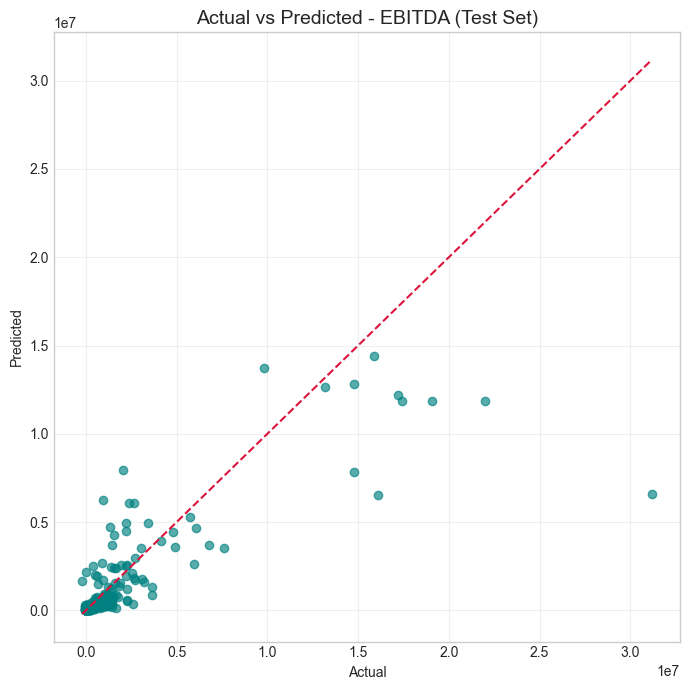

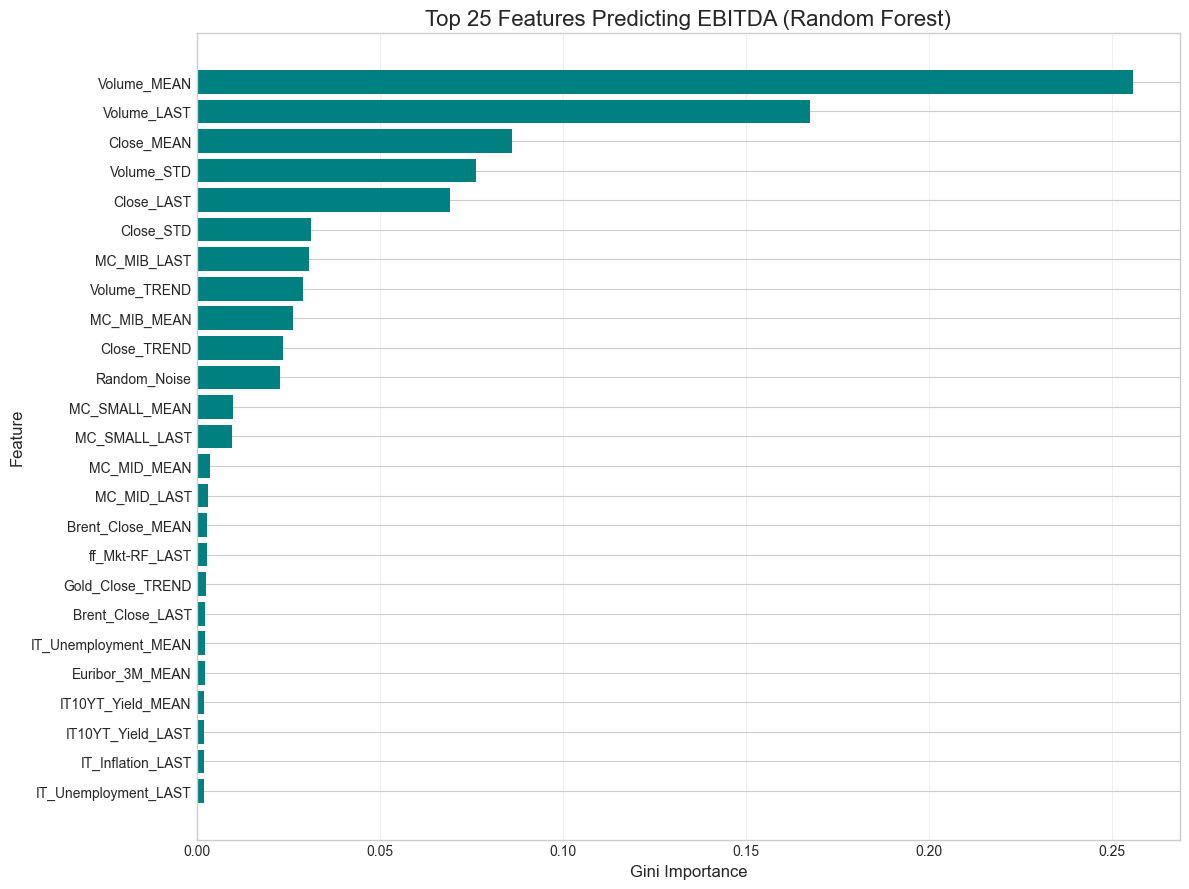

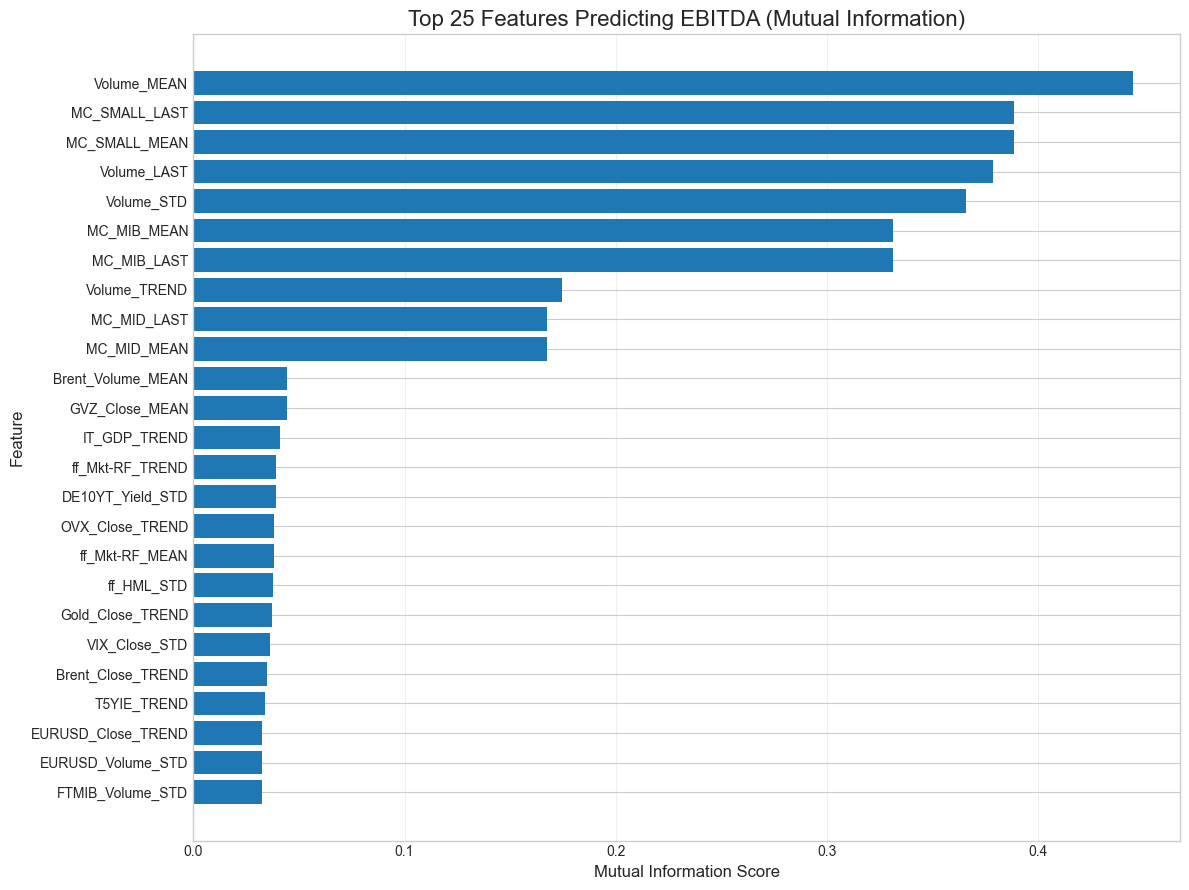

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/919617772.py:186: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


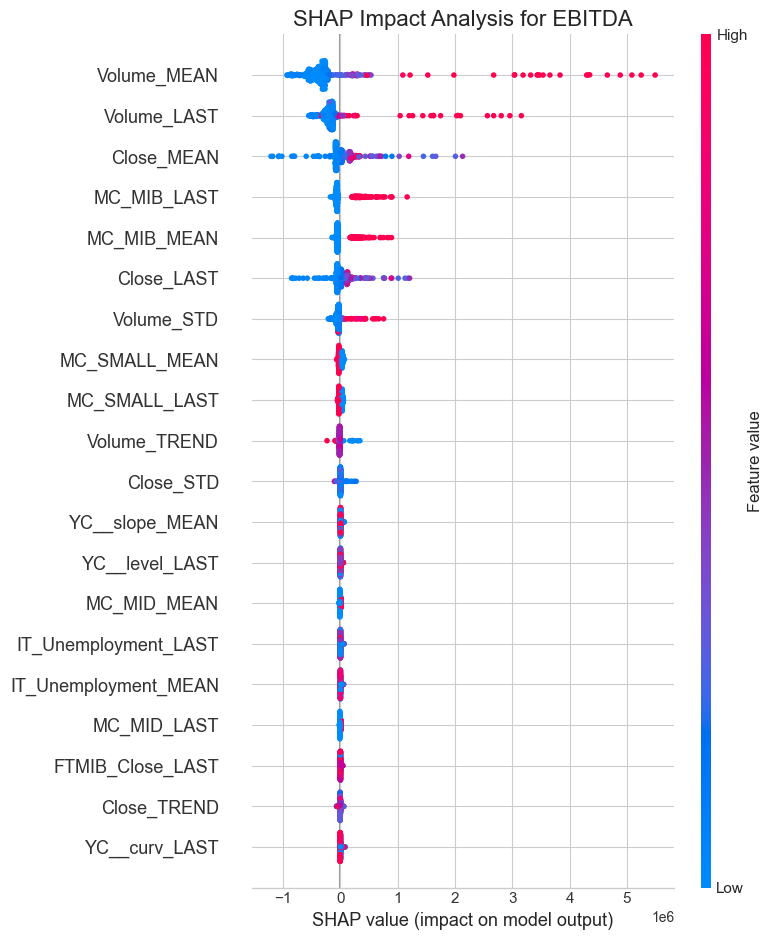


                                 ROA                                  
Total valid 90-day windows extracted: 2348

Top 10 features by Mutual Information:
         Feature  MI_Regression
    Volume_TREND       0.083708
     Volume_MEAN       0.077188
   MC_SMALL_MEAN       0.065838
   MC_SMALL_LAST       0.065838
      Volume_STD       0.062961
     Volume_LAST       0.057832
     MC_MIB_LAST       0.044492
     MC_MIB_MEAN       0.044492
      ff_HML_STD       0.023632
FTMIB_Volume_STD       0.022396

Model comparison (test metrics):
Raw Target RF  -> R2: -0.0232 | MAE: 0.1773 | RMSE: 1.3723 | Avg % Diff: 849.93% | WAPE: 136.89% | sMAPE: 135.34%
Signed-Log RF  -> R2: -0.0109 | MAE: 0.1303 | RMSE: 1.3640 | Avg % Diff: 378.95% | WAPE: 100.65% | sMAPE: 104.89%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 24, 'criterion': 'absolute_error', 'bootstrap': True}


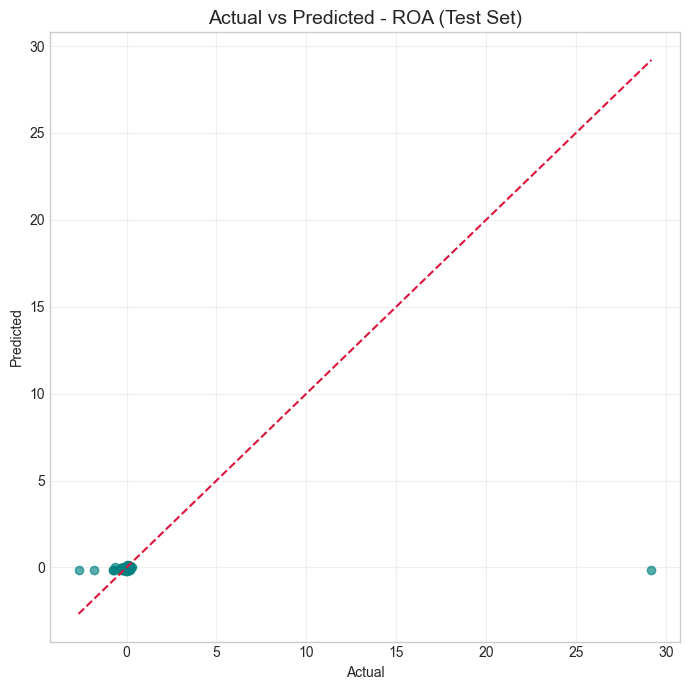

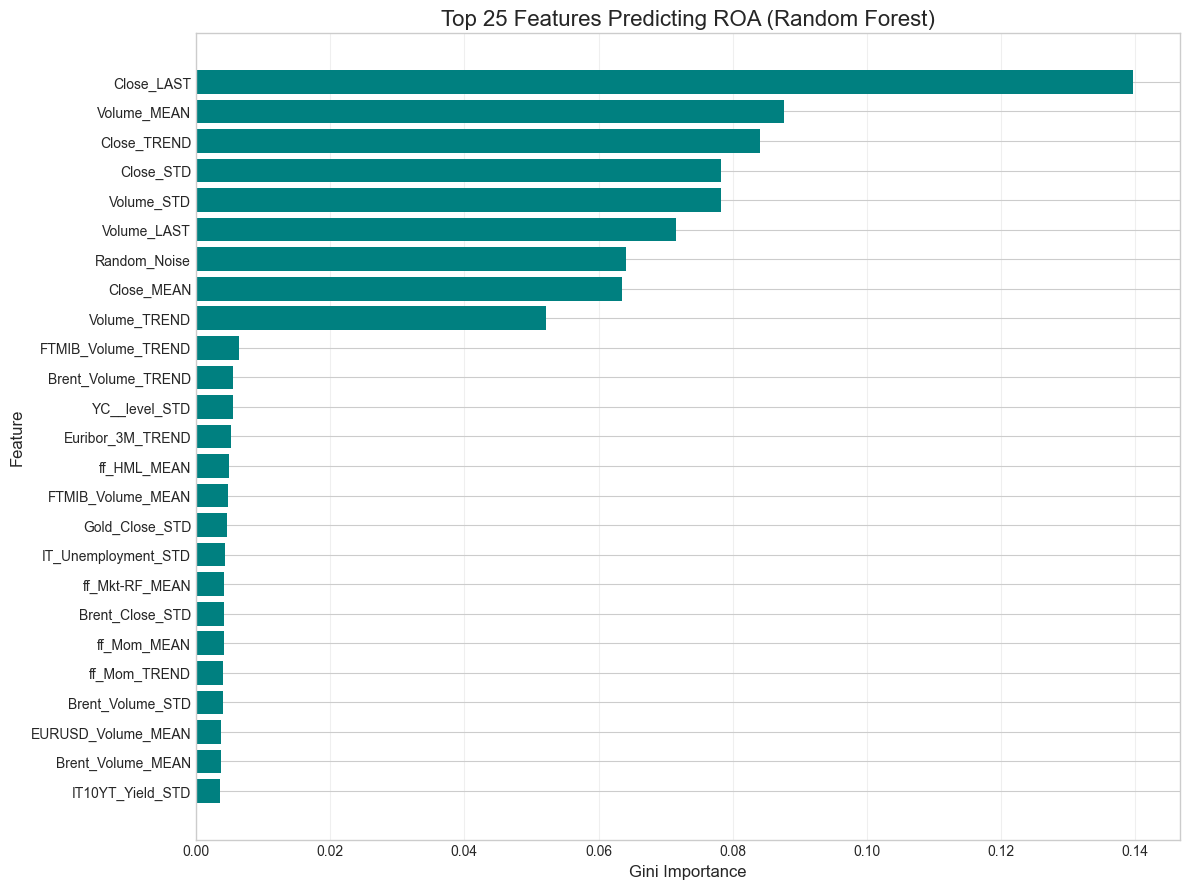

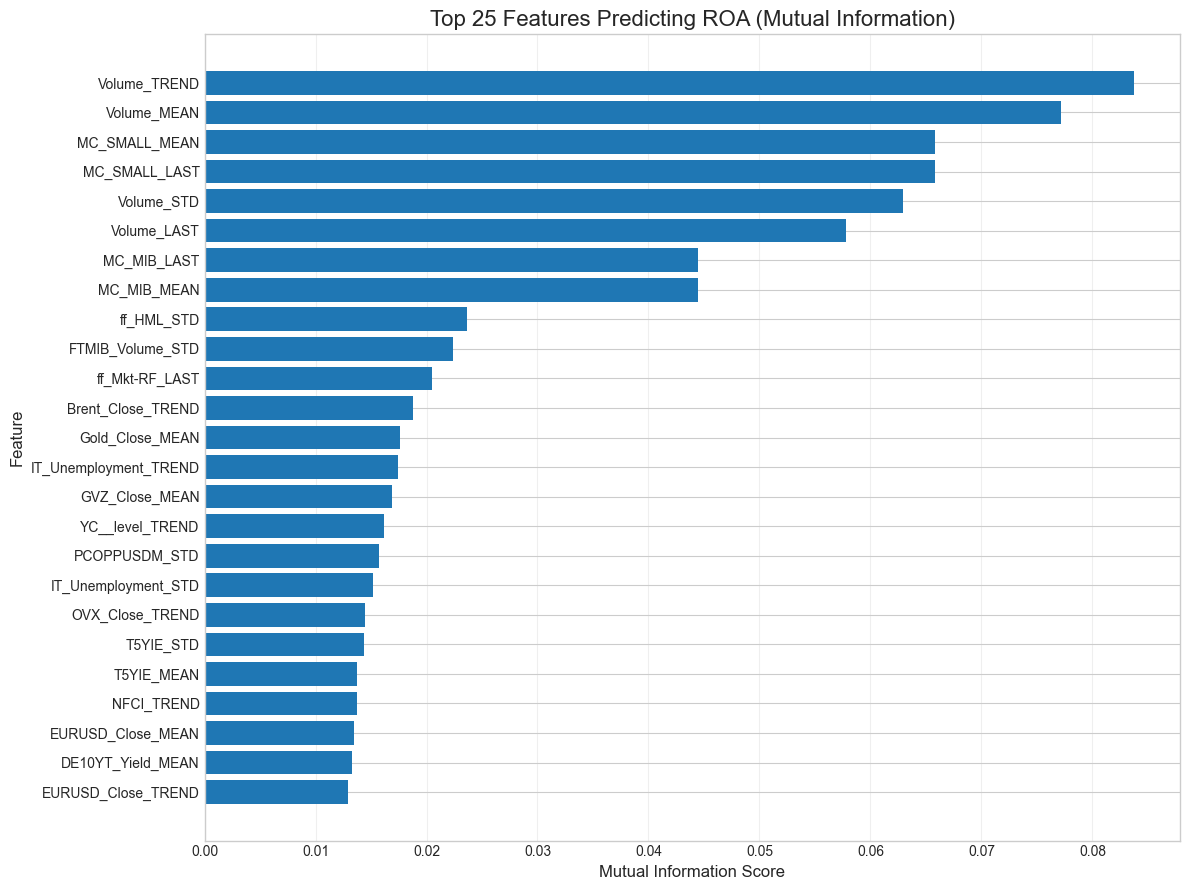

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/919617772.py:186: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


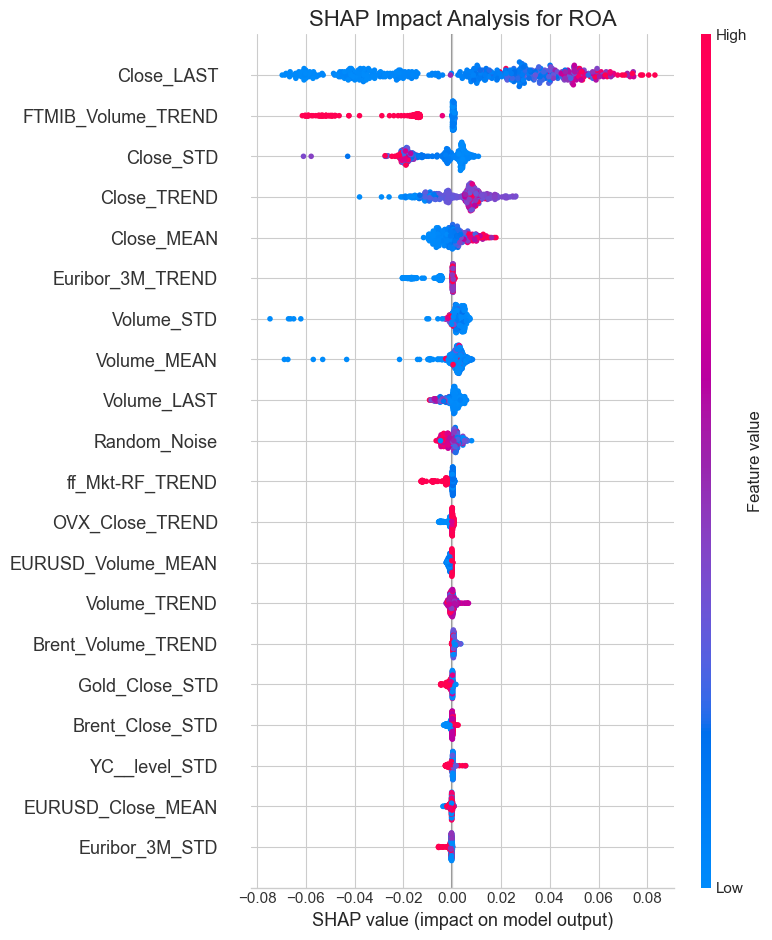


                              Net_Income                              
Total valid 90-day windows extracted: 2350

Top 10 features by Mutual Information:
      Feature  MI_Regression
MC_SMALL_LAST       0.340840
MC_SMALL_MEAN       0.340840
  Volume_MEAN       0.326400
  MC_MIB_MEAN       0.321033
  MC_MIB_LAST       0.321033
  Volume_LAST       0.320340
   Volume_STD       0.272007
 Volume_TREND       0.141501
  MC_MID_MEAN       0.140553
  MC_MID_LAST       0.140553

Model comparison (test metrics):
Raw Target RF  -> R2: 0.3707 | MAE: 292869.2054 | RMSE: 1222169.6934 | Avg % Diff: 223.23% | WAPE: 64.92% | sMAPE: 99.72%
Signed-Log RF  -> R2: -0.0485 | MAE: 431818.9581 | RMSE: 1577558.1931 | Avg % Diff: 106.27% | WAPE: 95.72% | sMAPE: 177.08%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}


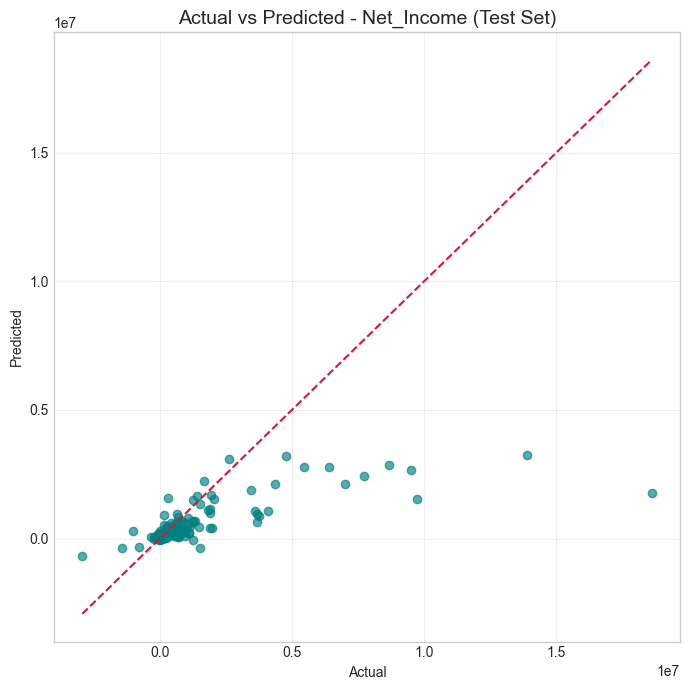

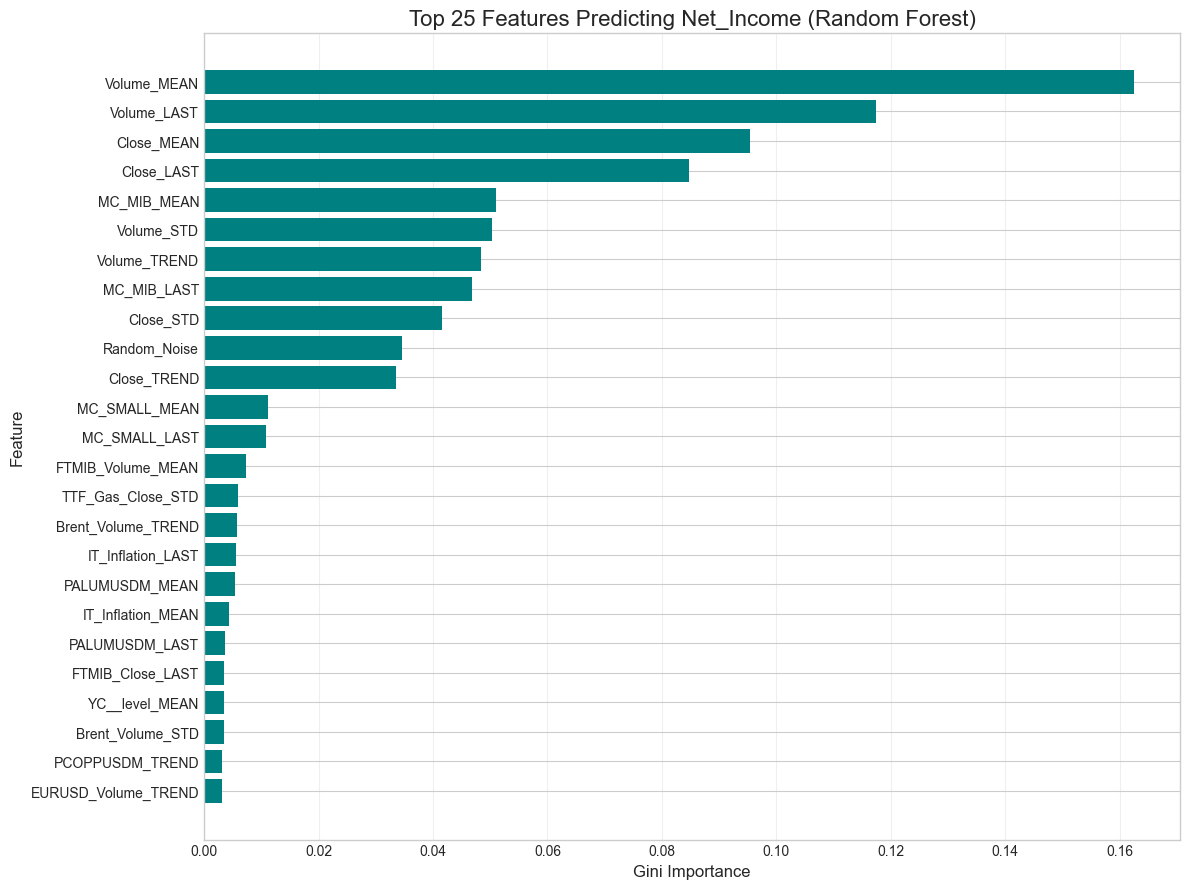

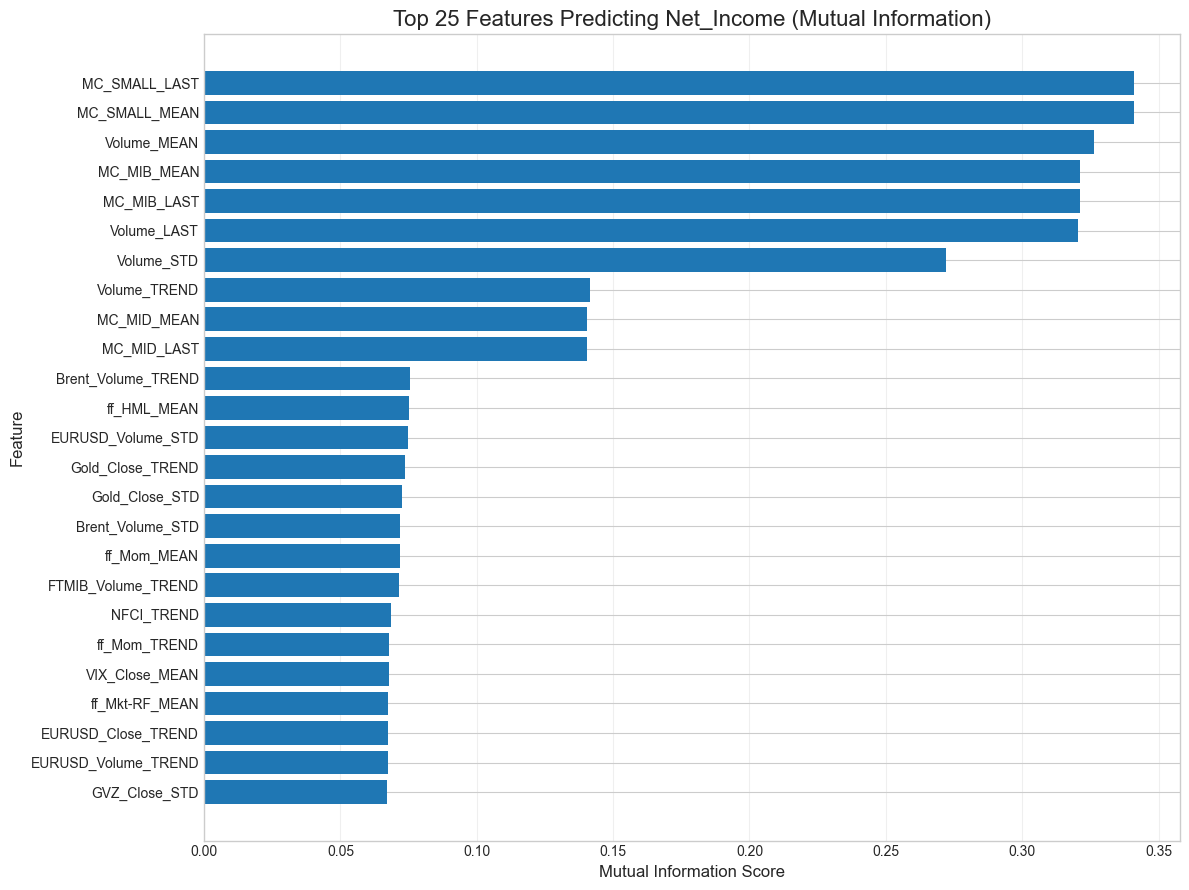

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/919617772.py:186: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


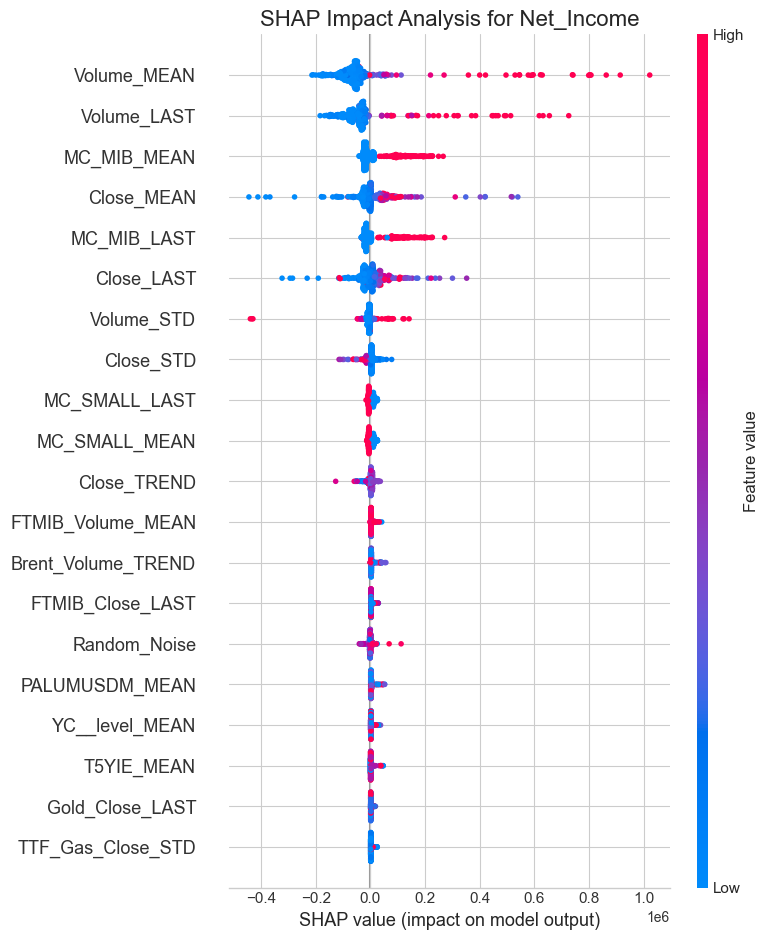


Final Test Performance Summary (selected model per target)
    Target           Selected_Model   Test_R2    Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%     WAPE_%    sMAPE_%
    EBITDA Raw-Target RF (selected)  0.678172 1.628043e+06 454934.065028    238.662603        55.439251  50.702802  73.872084
       ROA Signed-Log RF (selected) -0.010864 1.364010e+00      0.130323    378.945261        83.946762 100.647888 104.890021
Net_Income Raw-Target RF (selected)  0.370685 1.222170e+06 292869.205398    223.230899        70.027674  64.918059  99.720975


In [39]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=90)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 40:
                continue

            window_stats = {'Company': company, 'Target_Date': target_date, 'Random_Noise': float(np.random.normal(0, 1))}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    if feat in categorical_features:
                        window_stats[f"{feat}_LAST"] = np.nan
                    else:
                        window_stats[f"{feat}_MEAN"] = np.nan
                        window_stats[f"{feat}_STD"] = np.nan
                        window_stats[f"{feat}_LAST"] = np.nan
                        window_stats[f"{feat}_TREND"] = np.nan
                else:
                    values = series.values.astype(float)
                    if feat in categorical_features:
                        window_stats[f"{feat}_LAST"] = float(values[-1])
                    else:
                        window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                        window_stats[f"{feat}_STD"] = float(np.std(values, ddof=1))
                        window_stats[f"{feat}_LAST"] = float(values[-1])

                        if len(values) > 1:
                            x_axis = np.arange(len(values), dtype=float)
                            slope = np.polyfit(x_axis, values, deg=1)[0]
                        else:
                            slope = np.nan
                        window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 90-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    # Missing values handled by median imputation after train/test split
    
    # Time-based split to prevent leakage
    X_df['Target_Date'] = pd.to_datetime(X_df['Target_Date'])
    sort_idx = X_df.sort_values('Target_Date').index
    X_df = X_df.loc[sort_idx].reset_index(drop=True)
    y_series = y_series.loc[sort_idx].reset_index(drop=True)
    X_df = X_df.drop(columns=['Company', 'Target_Date'])
    
    split_idx = int(len(X_df) * 0.8)
    X_train, X_test = X_df.iloc[:split_idx], X_df.iloc[split_idx:]
    y_train, y_test = y_series.iloc[:split_idx], y_series.iloc[split_idx:]

    # Impute missing values with median (fit on train only to prevent leakage)
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='regression')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Gini Importance
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Mutual Information
    top_mi = mi_df.head(25).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 9))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

### YoY: Exogenous Variables Only


                                EBITDA                                
Total valid 365-day windows extracted: 2138

Top 10 features by Mutual Information:
       Feature  MI_Regression
   Volume_MEAN       0.450187
 MC_SMALL_LAST       0.405590
    Volume_STD       0.396583
   Volume_LAST       0.375960
   MC_MIB_LAST       0.330651
  Volume_TREND       0.204004
   MC_MID_LAST       0.186427
   ff_HML_MEAN       0.081700
ff_Mkt-RF_MEAN       0.078711
   ff_Mom_MEAN       0.073743

Model comparison (test metrics):
Raw Target RF  -> R2: 0.5337 | MAE: 654561.4135 | RMSE: 2464824.7250 | Avg % Diff: 211.49% | WAPE: 58.65% | sMAPE: 75.05%
Signed-Log RF  -> R2: 0.1497 | MAE: 905822.1636 | RMSE: 3328388.5625 | Avg % Diff: 105.61% | WAPE: 81.16% | sMAPE: 141.76%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True

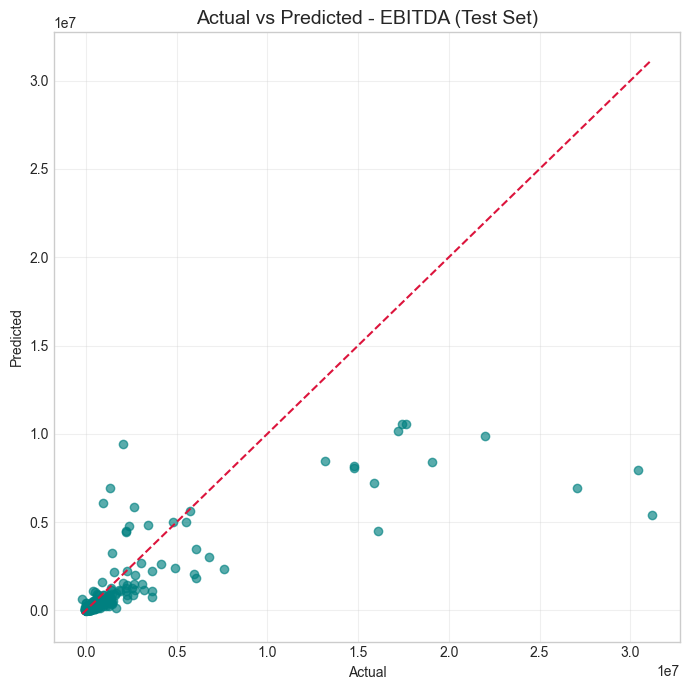

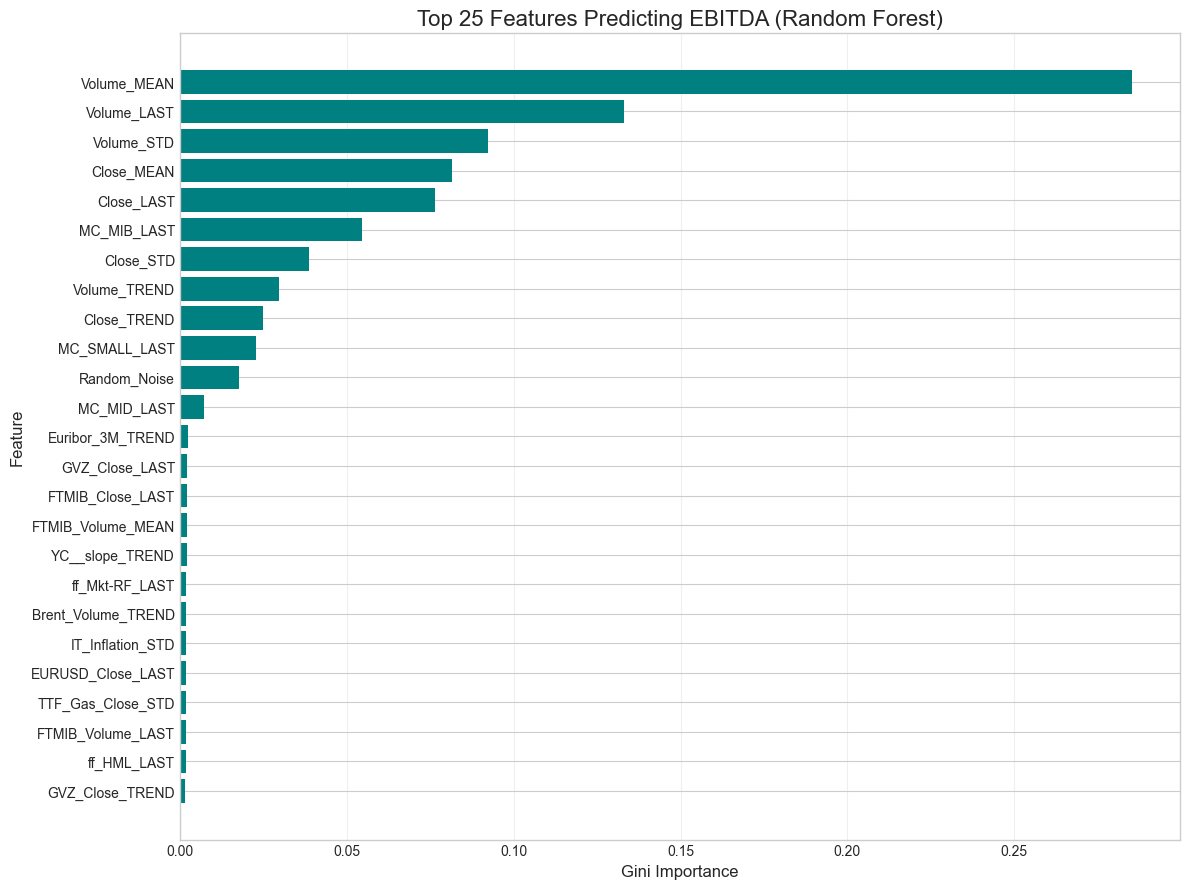

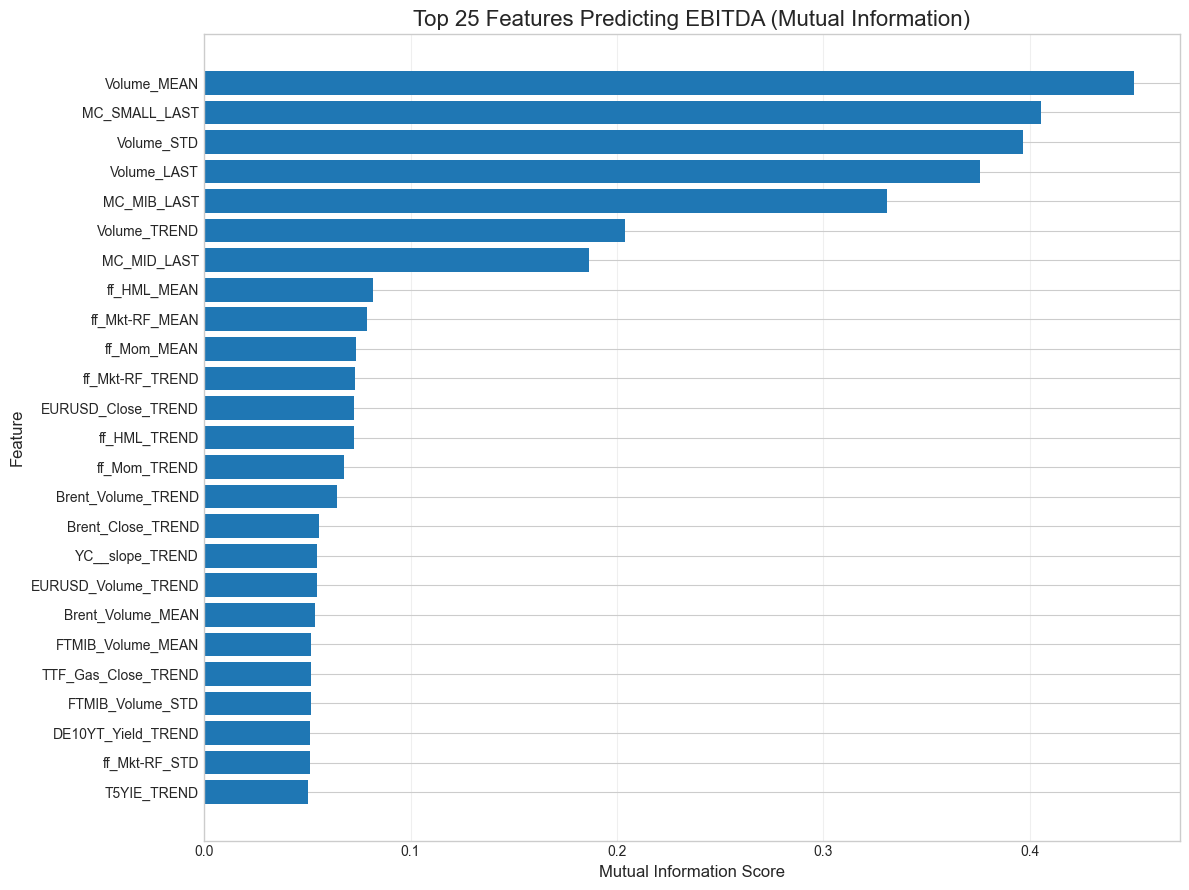

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/4150028914.py:193: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


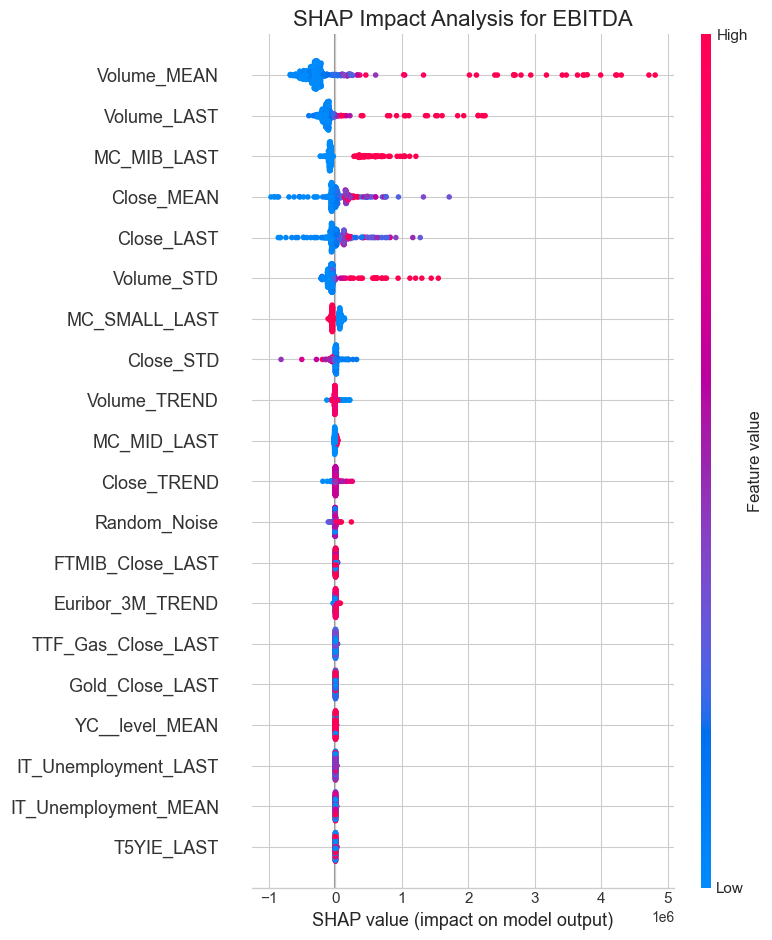


                                 ROA                                  
Total valid 365-day windows extracted: 2172

Top 10 features by Mutual Information:
          Feature  MI_Regression
       Volume_STD       0.072873
      Volume_MEAN       0.063824
    MC_SMALL_LAST       0.058680
      MC_MIB_LAST       0.058139
     Volume_TREND       0.053371
      Volume_LAST       0.050023
Brent_Close_TREND       0.043559
 IT_Inflation_STD       0.037947
    GVZ_Close_STD       0.037533
   Gold_Close_STD       0.037375

Model comparison (test metrics):
Raw Target RF  -> R2: -0.0132 | MAE: 0.1356 | RMSE: 1.4193 | Avg % Diff: 269.58% | WAPE: 100.00% | sMAPE: 117.44%
Signed-Log RF  -> R2: -0.0091 | MAE: 0.1327 | RMSE: 1.4164 | Avg % Diff: 247.60% | WAPE: 97.84% | sMAPE: 114.62%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 24, 'criterion': 'absolute_error', 'bootstr

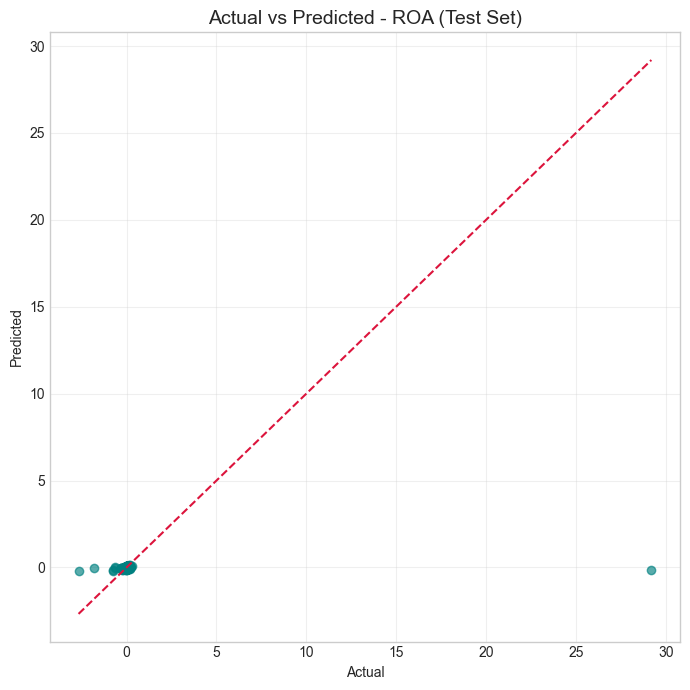

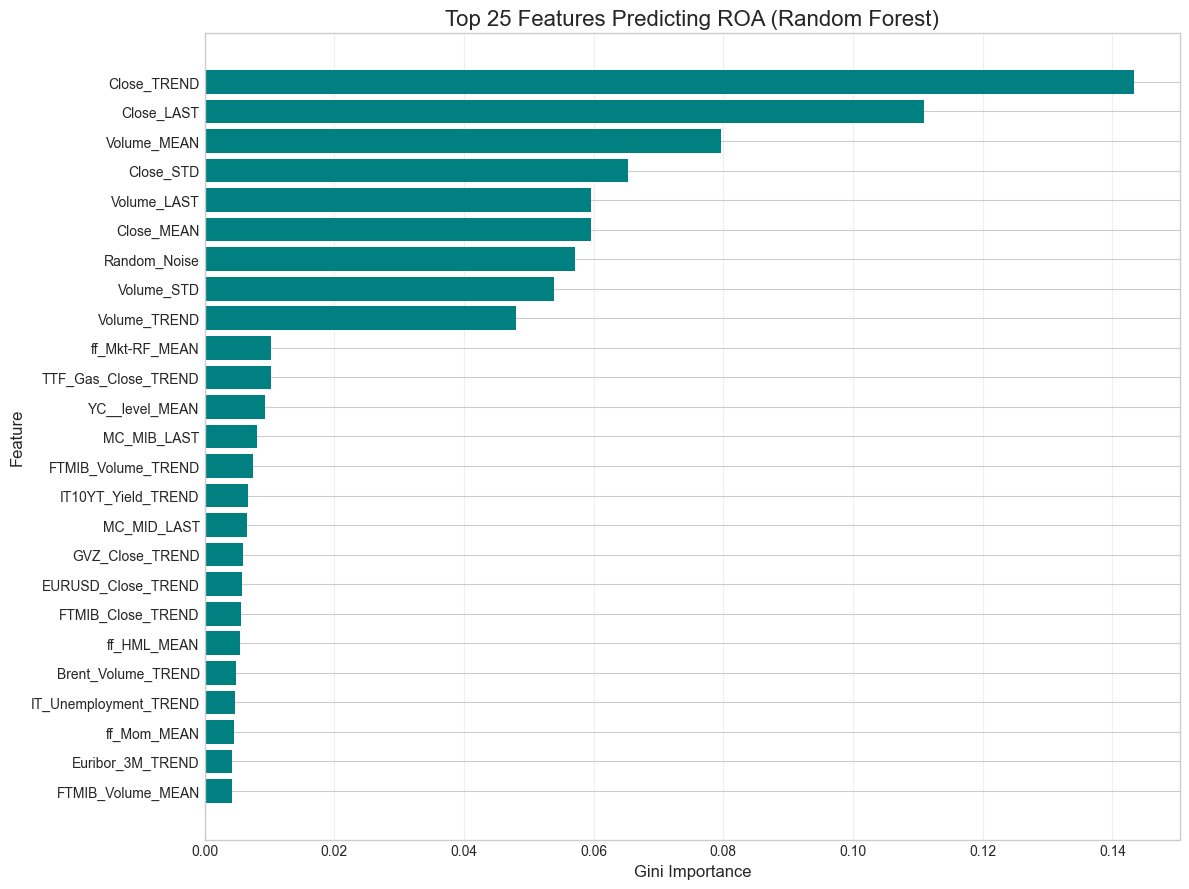

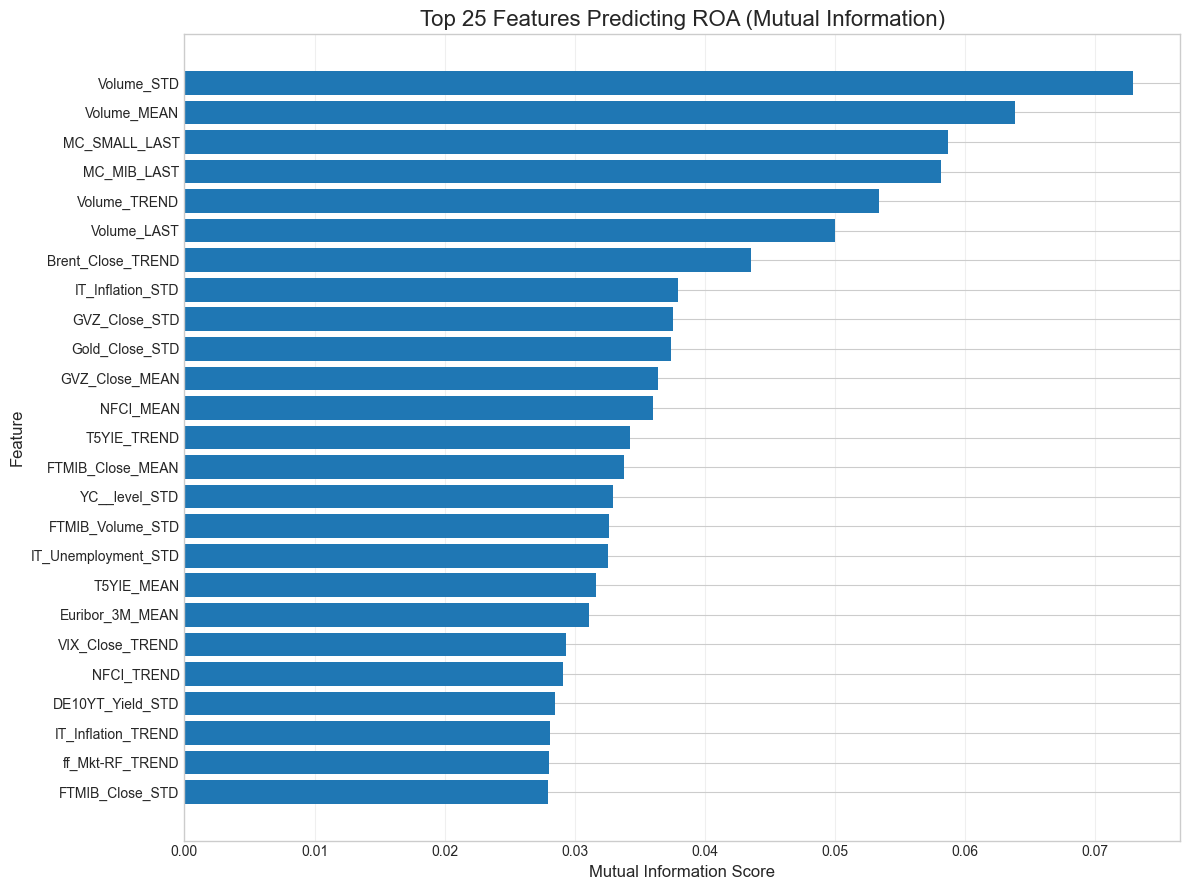

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/4150028914.py:193: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


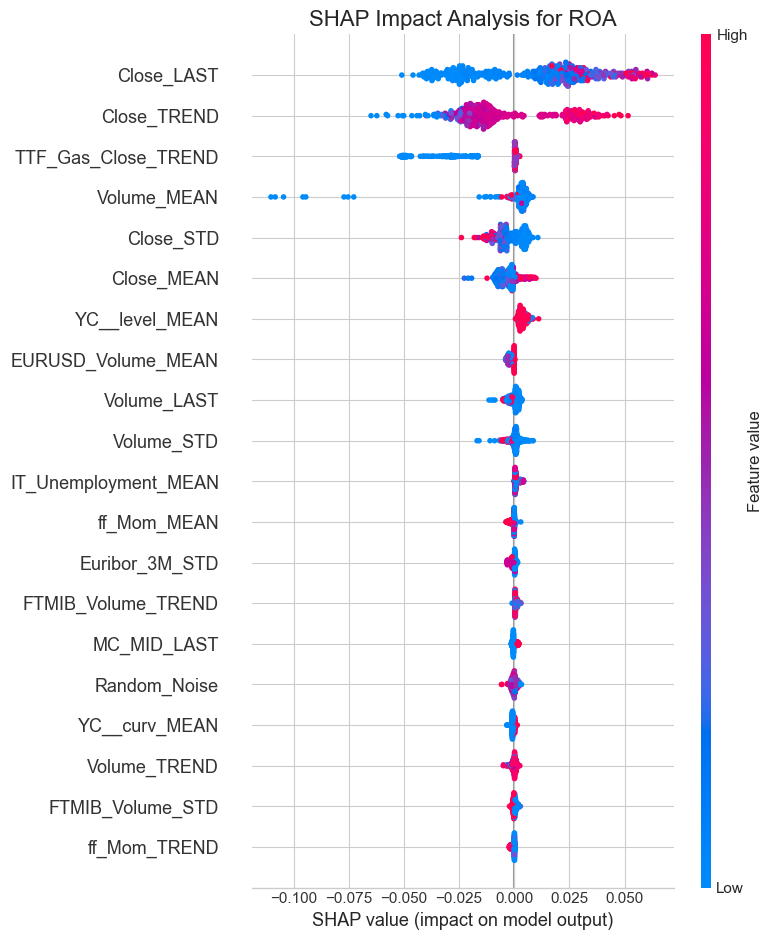


                              Net_Income                              
Total valid 365-day windows extracted: 2174

Top 10 features by Mutual Information:
       Feature  MI_Regression
   Volume_MEAN       0.401671
 MC_SMALL_LAST       0.356452
   MC_MIB_LAST       0.325863
   Volume_LAST       0.307373
    Volume_STD       0.273507
   MC_MID_LAST       0.158616
  Volume_TREND       0.132785
   ff_HML_MEAN       0.122005
   ff_Mom_MEAN       0.120936
ff_Mkt-RF_MEAN       0.117537

Model comparison (test metrics):
Raw Target RF  -> R2: 0.3257 | MAE: 302805.8060 | RMSE: 1275399.6028 | Avg % Diff: 185.88% | WAPE: 67.91% | sMAPE: 102.72%
Signed-Log RF  -> R2: 0.0674 | MAE: 401162.5372 | RMSE: 1499980.9249 | Avg % Diff: 93.01% | WAPE: 89.96% | sMAPE: 171.22%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstr

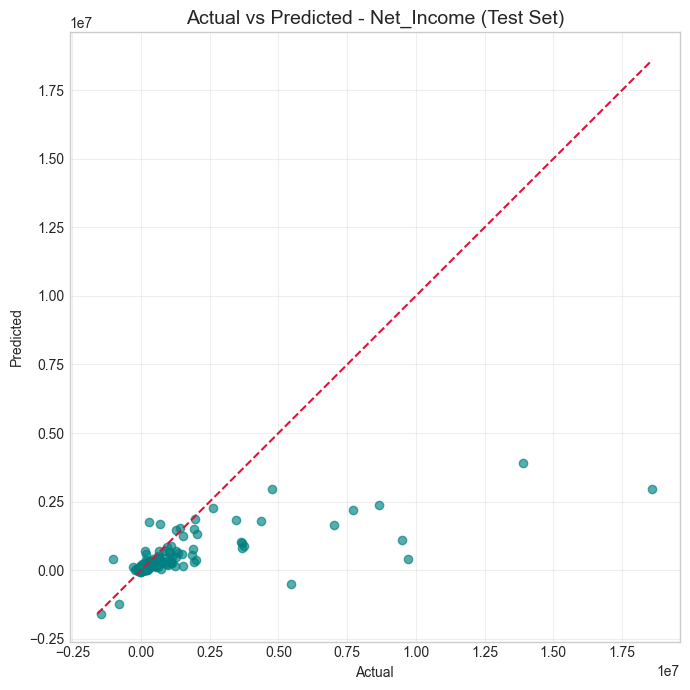

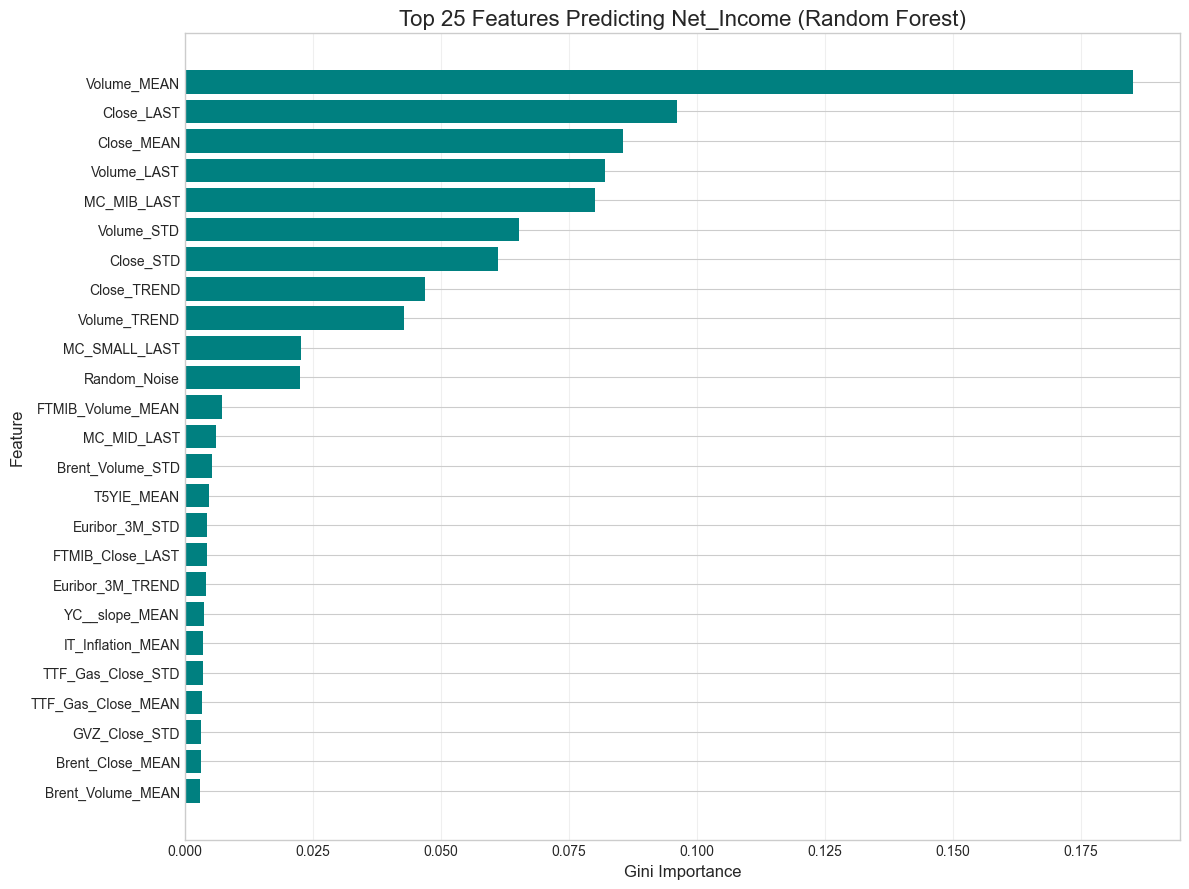

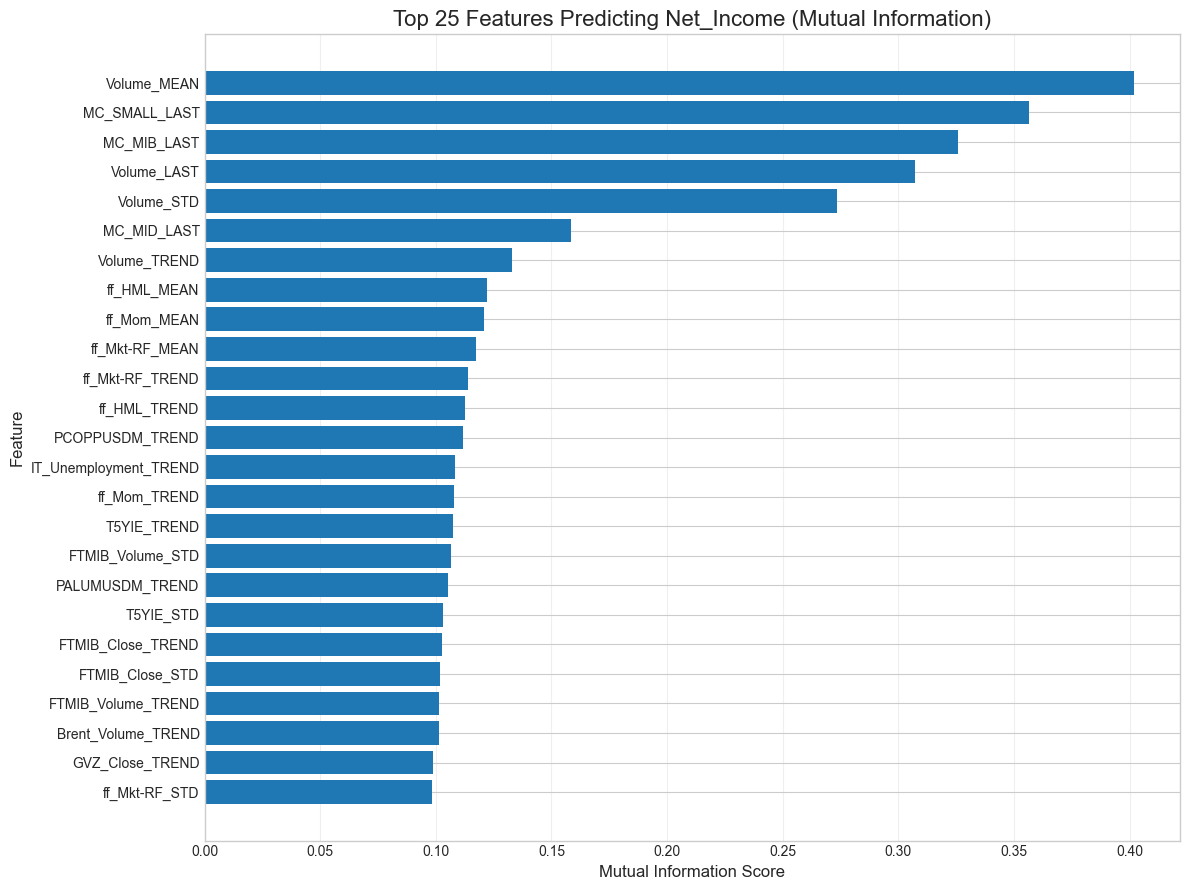

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/4150028914.py:193: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


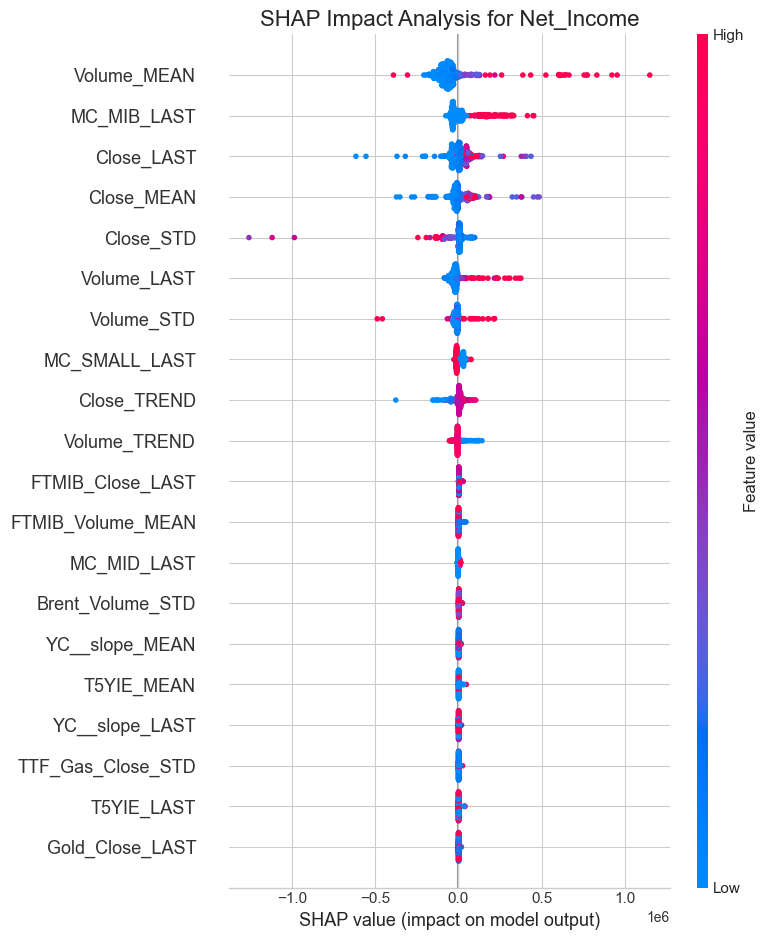


Final Test Performance Summary (selected model per target)
    Target           Selected_Model   Test_R2    Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%    WAPE_%    sMAPE_%
    EBITDA Raw-Target RF (selected)  0.533665 2.464825e+06 654561.413513    211.488784        56.455646 58.645043  75.046354
       ROA Signed-Log RF (selected) -0.009055 1.416386e+00      0.132703    247.600699        90.842049 97.840625 114.621704
Net_Income Raw-Target RF (selected)  0.325738 1.275400e+06 302805.805998    185.880794        70.950914 67.905213 102.715373


In [53]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 200:
                continue

            window_stats = {'Company': company, 'Target_Date': target_date, 'Random_Noise': float(np.random.normal(0, 1))}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    if feat in categorical_features:
                        window_stats[f"{feat}_LAST"] = np.nan
                    else:
                        window_stats[f"{feat}_MEAN"] = np.nan
                        window_stats[f"{feat}_STD"] = np.nan
                        window_stats[f"{feat}_LAST"] = np.nan
                        window_stats[f"{feat}_TREND"] = np.nan
                else:
                    values = series.values.astype(float)
                    if feat in categorical_features:
                        window_stats[f"{feat}_LAST"] = float(values[-1])
                    else:
                        window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                        window_stats[f"{feat}_STD"] = float(np.std(values, ddof=1))
                        window_stats[f"{feat}_LAST"] = float(values[-1])

                        if len(values) > 1:
                            x_axis = np.arange(len(values), dtype=float)
                            slope = np.polyfit(x_axis, values, deg=1)[0]
                        else:
                            slope = np.nan
                        window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 365-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    # Missing values handled by median imputation after train/test split
    
    # Time-based split to prevent leakage
    X_df['Target_Date'] = pd.to_datetime(X_df['Target_Date'])
    sort_idx = X_df.sort_values('Target_Date').index
    X_df = X_df.loc[sort_idx].reset_index(drop=True)
    y_series = y_series.loc[sort_idx].reset_index(drop=True)
    X_df = X_df.drop(columns=['Company', 'Target_Date'])
    
    split_idx = int(len(X_df) * 0.8)
    X_train, X_test = X_df.iloc[:split_idx], X_df.iloc[split_idx:]
    y_train, y_test = y_series.iloc[:split_idx], y_series.iloc[split_idx:]

    # Impute missing values with median (fit on train only to prevent leakage)
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='regression')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Gini Importance
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Mutual Information
    top_mi = mi_df.head(25).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 9))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 2: YoY Signed-Log Differences Target Analysis



                         EBITDA_SignedLogDiff                         
Total valid 365-day windows extracted: 2126

Top 10 features by Mutual Information:
           Feature  MI_Regression
    PALUMUSDM_MEAN       0.080771
TTF_Gas_Close_LAST       0.077782
  DE10YT_Yield_STD       0.077781
  FTMIB_Close_LAST       0.075634
 IT10YT_Yield_LAST       0.074630
 EURUSD_Close_MEAN       0.074360
 EURUSD_Close_LAST       0.073544
 IT10YT_Yield_MEAN       0.072732
EURUSD_Volume_MEAN       0.072570
    PCOPPUSDM_MEAN       0.072159

Best RF Params for EBITDA_SignedLogDiff: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_depth': 32, 'criterion': 'squared_error', 'bootstrap': True}
Train -> MAE: 2.2817 | RMSE: 5.0045 | R2: 0.3954 | Avg % Diff: 6385355.77% | Median % Diff: 153.96% | WAPE: 95.72% | sMAPE: 127.33%
Test  -> MAE: 2.1301 | RMSE: 4.7786 | R2: -0.0245 | Avg % Diff: 1836.36% | Median % Diff: 362.78% | WAPE: 146.55% | sMAPE: 153.30%


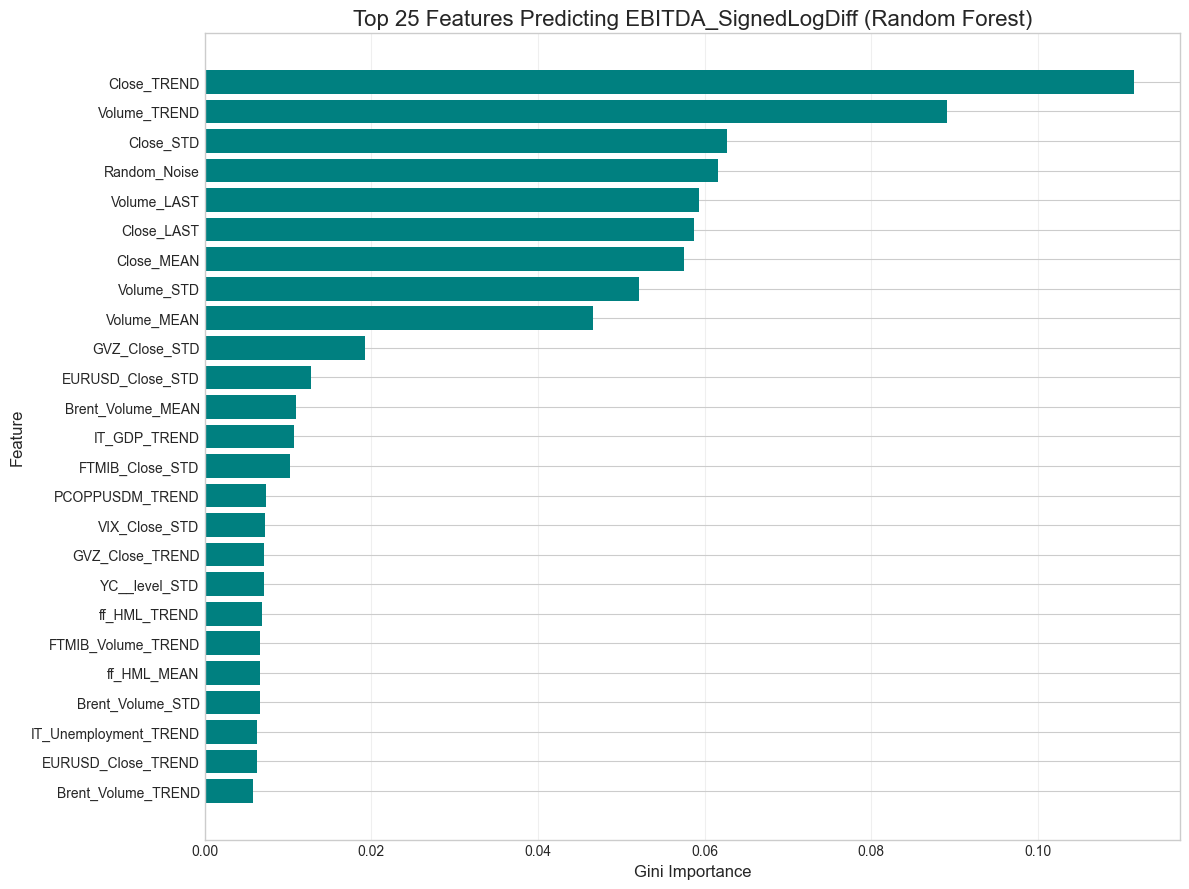

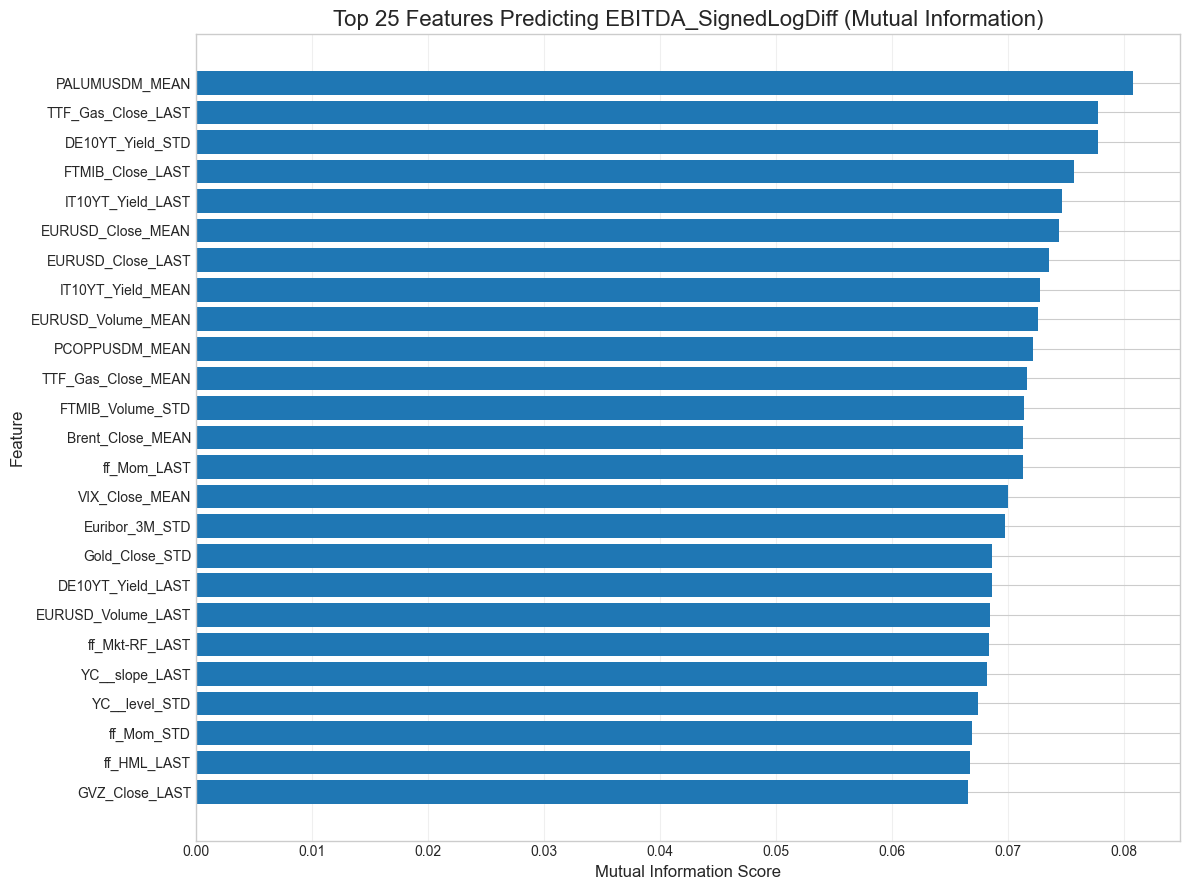

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/3125248465.py:147: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


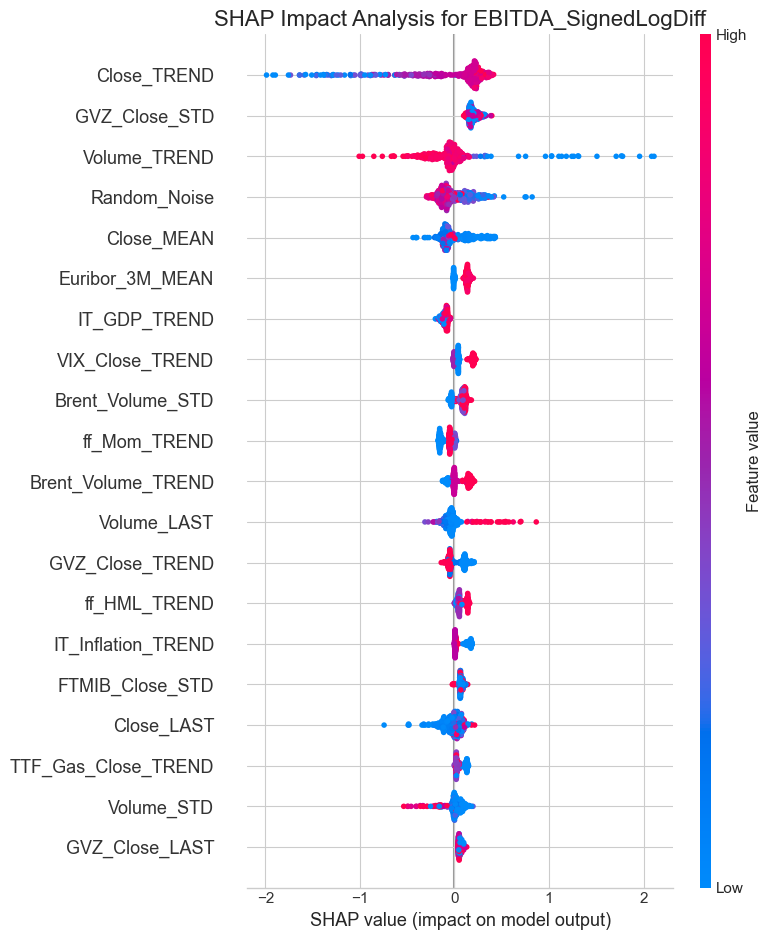


                          ROA_SignedLogDiff                           
Total valid 365-day windows extracted: 2164

Top 10 features by Mutual Information:
            Feature  MI_Regression
        Volume_MEAN       0.057385
      MC_SMALL_LAST       0.055160
IT_Unemployment_STD       0.052709
        Volume_LAST       0.051653
           NFCI_STD       0.047817
  Brent_Volume_MEAN       0.046970
      YC__slope_STD       0.046711
    YC__level_TREND       0.045798
   EURUSD_Close_STD       0.044999
 IT_Inflation_TREND       0.044997

Best RF Params for ROA_SignedLogDiff: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0376 | RMSE: 0.1654 | R2: 0.1315 | Avg % Diff: 45643.92% | Median % Diff: 70.66% | WAPE: 78.46% | sMAPE: 103.37%
Test  -> MAE: 0.0632 | RMSE: 0.2980 | R2: 0.0078 | Avg % Diff: 913.55% | Median % Diff: 167.03% | WAPE: 115.94% | sMAPE: 152.90%


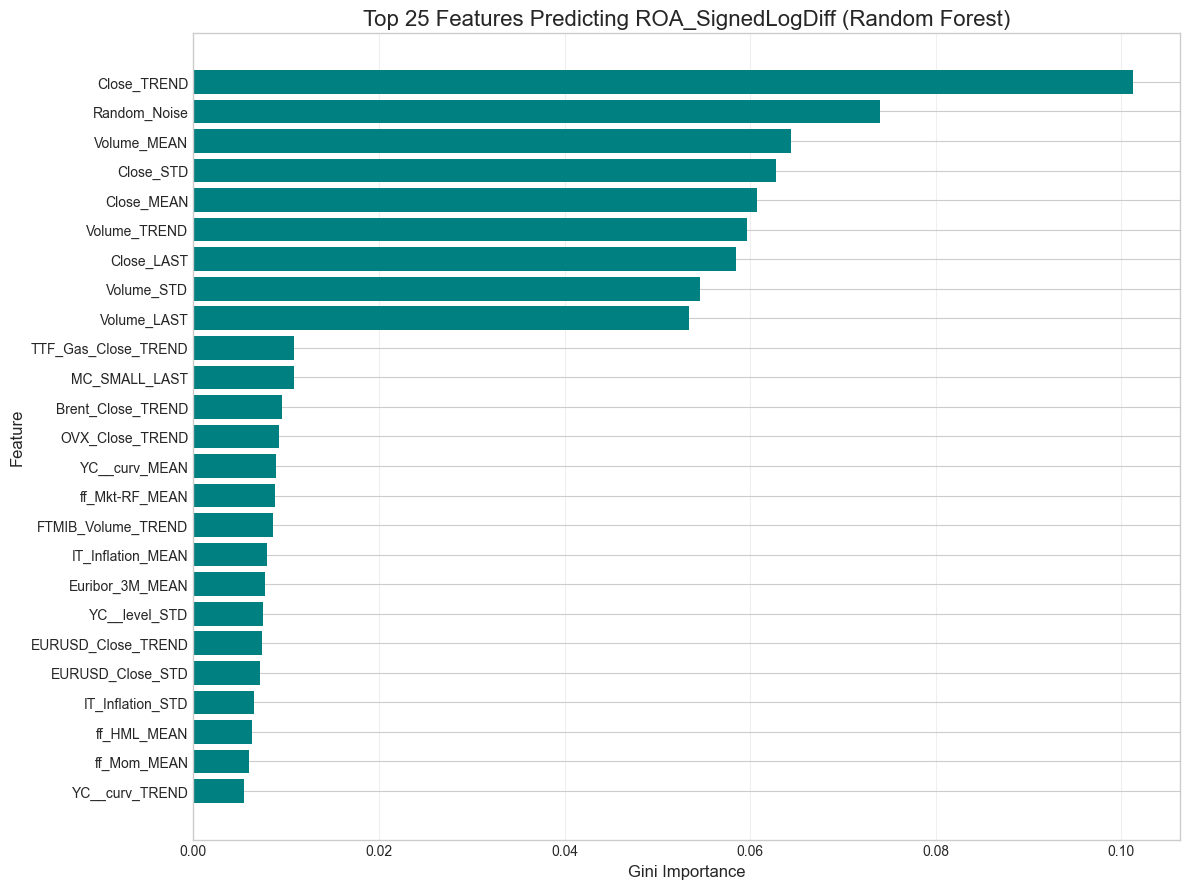

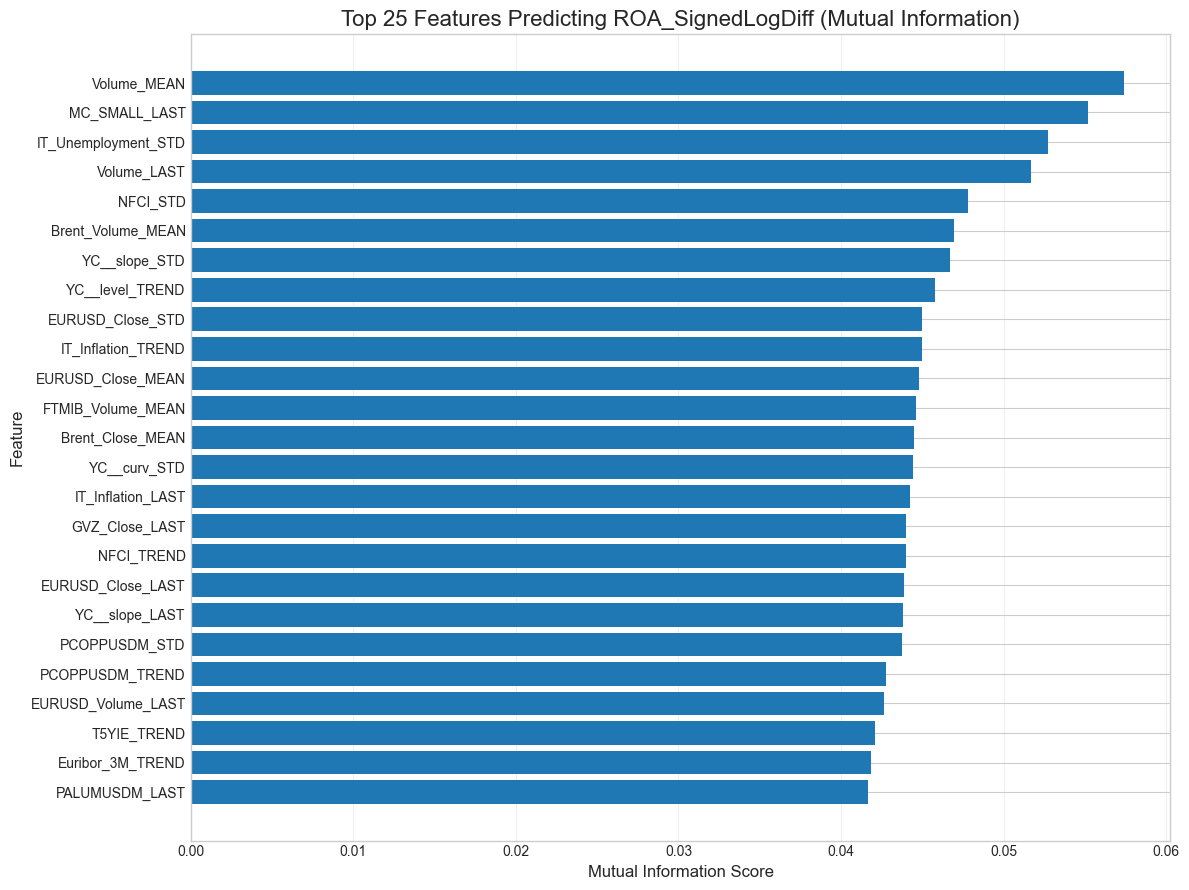

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/3125248465.py:147: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


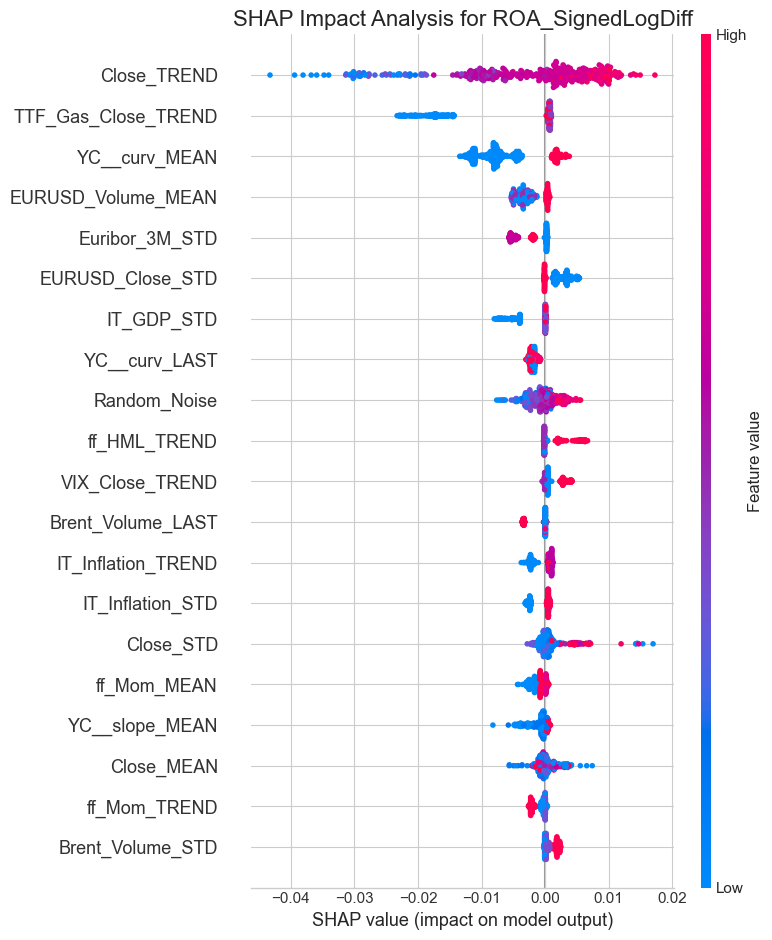


                       Net_Income_SignedLogDiff                       
Total valid 365-day windows extracted: 2166

Top 10 features by Mutual Information:
           Feature  MI_Regression
       Volume_MEAN       0.089542
     MC_SMALL_LAST       0.083968
       MC_MIB_LAST       0.080967
        Volume_STD       0.069868
EURUSD_Volume_MEAN       0.066291
  IT_Inflation_STD       0.064315
    Gold_Close_STD       0.063970
  Brent_Volume_STD       0.063719
 EURUSD_Volume_STD       0.062206
  FTMIB_Volume_STD       0.058116

Best RF Params for Net_Income_SignedLogDiff: {'n_estimators': 1000, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'criterion': 'squared_error', 'bootstrap': True}
Train -> MAE: 3.8990 | RMSE: 7.0206 | R2: 0.3398 | Avg % Diff: 5366591.98% | Median % Diff: 141.37% | WAPE: 94.89% | sMAPE: 137.03%
Test  -> MAE: 3.1888 | RMSE: 6.6383 | R2: -0.0184 | Avg % Diff: 1161.98% | Median % Diff: 268.57% | WAPE: 120.01% | sMAPE: 157.00%

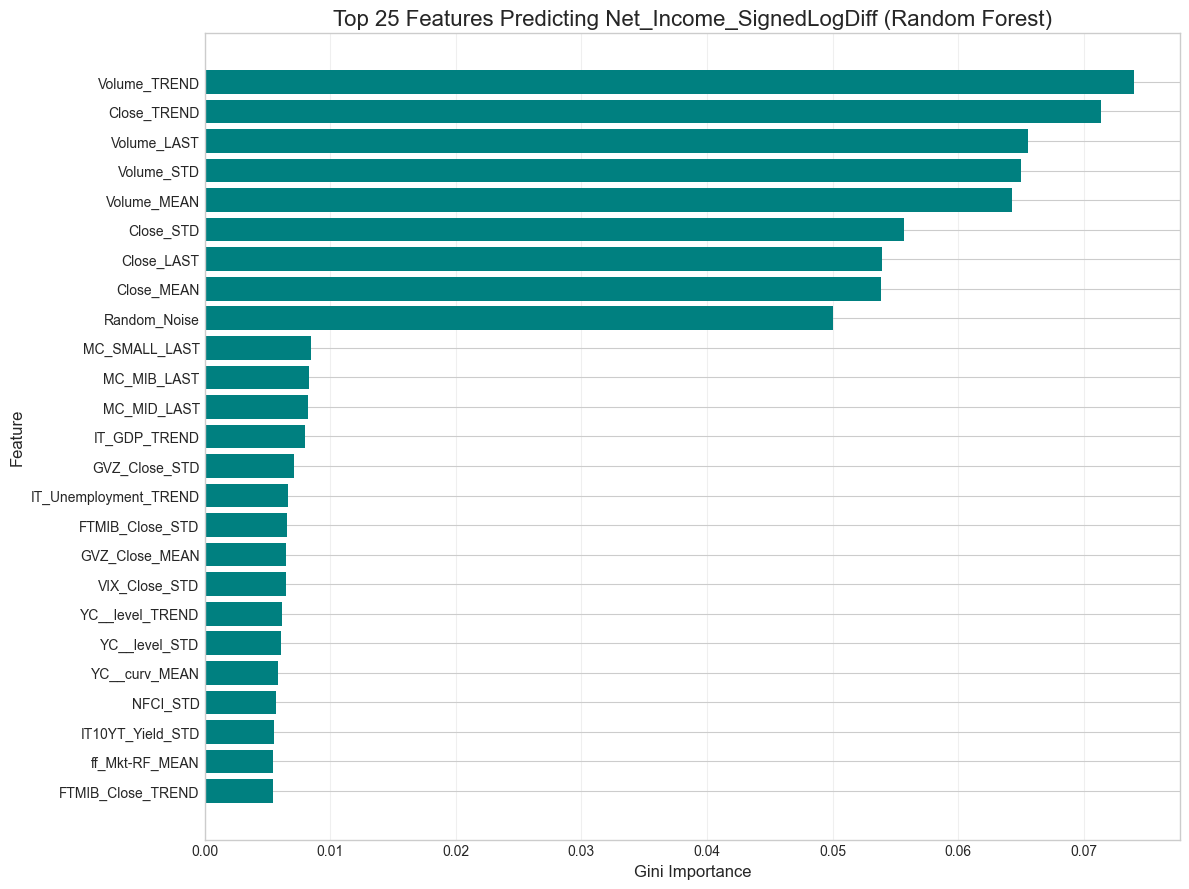

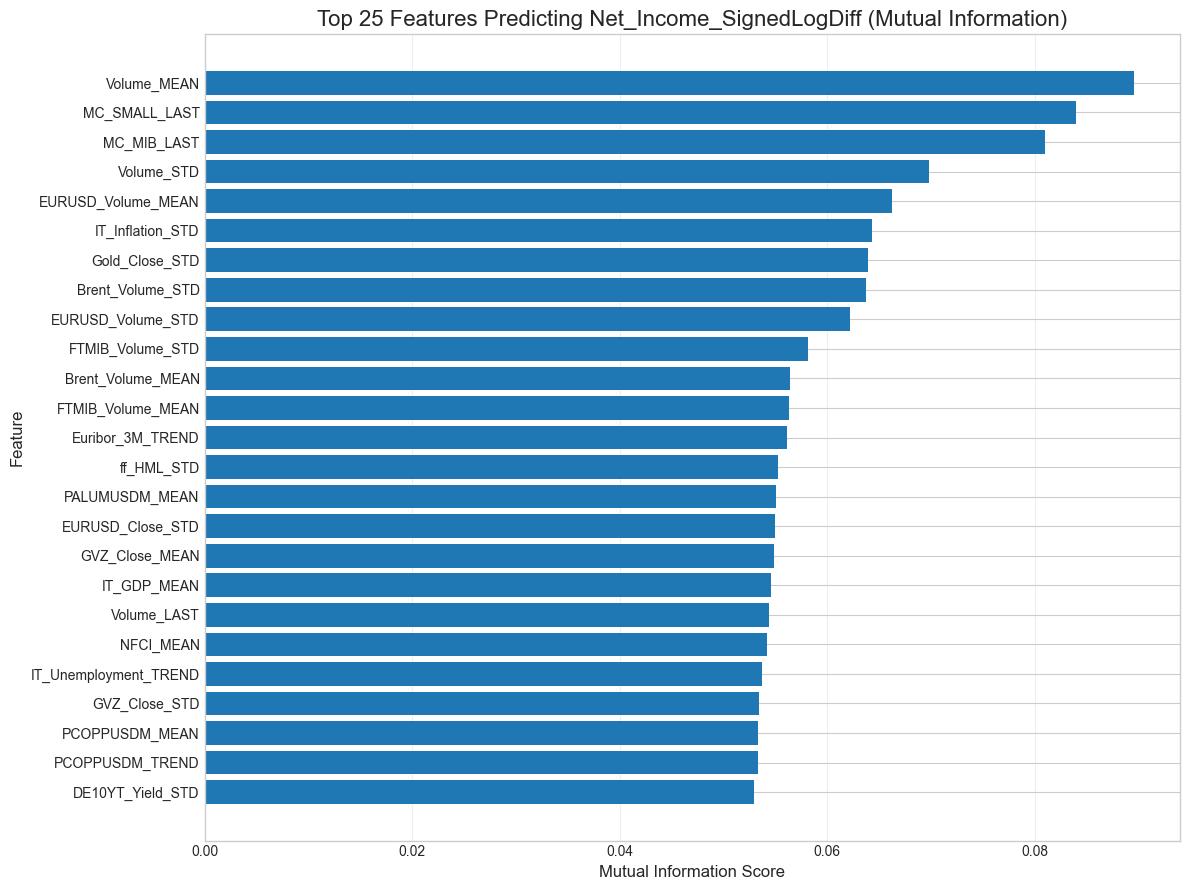

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/3125248465.py:147: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)


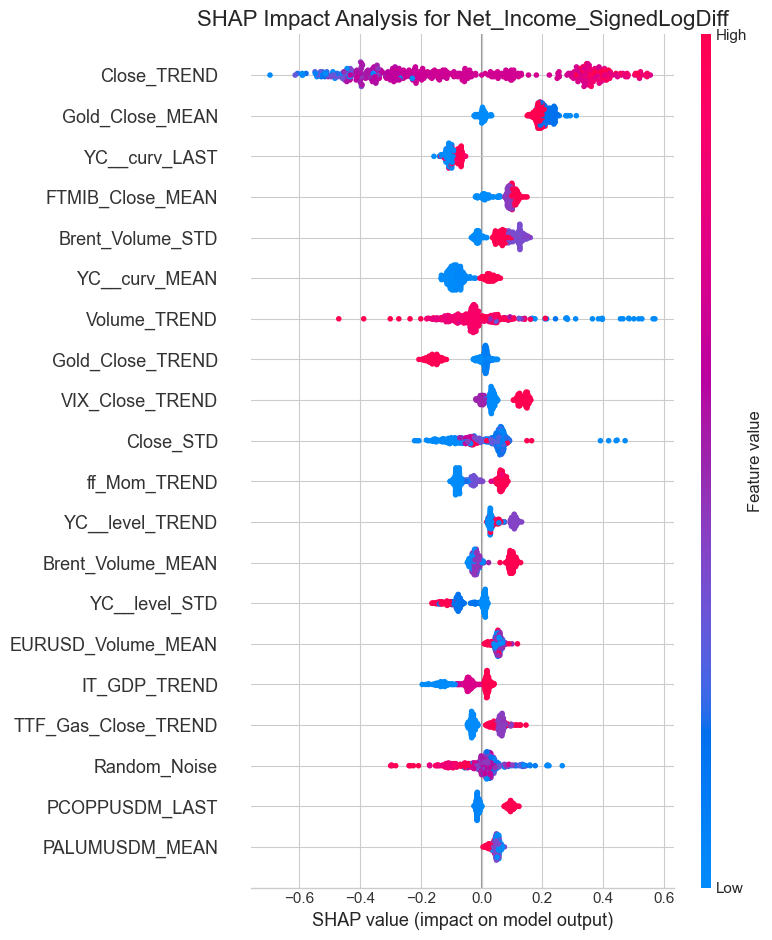


Final Test Performance Summary (Momentum Models)
                  Target   Test_R2  Test_RMSE  Test_MAE  AvgPctDiff_%  MedianPctDiff_%     WAPE_%    sMAPE_%
    EBITDA_SignedLogDiff -0.024470   4.778584  2.130054   1836.357061       362.778745 146.551878 153.303866
       ROA_SignedLogDiff  0.007789   0.297974  0.063164    913.553853       167.026928 115.942893 152.901337
Net_Income_SignedLogDiff -0.018354   6.638287  3.188756   1161.976081       268.571767 120.010593 156.999852


In [54]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in log_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 200:
                continue

            window_stats = {'Company': company, 'Target_Date': target_date, 'Random_Noise': float(np.random.normal(0, 1))}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    if feat in categorical_features:
                        window_stats[f"{feat}_LAST"] = np.nan
                    else:
                        window_stats[f"{feat}_MEAN"] = np.nan
                        window_stats[f"{feat}_STD"] = np.nan
                        window_stats[f"{feat}_LAST"] = np.nan
                        window_stats[f"{feat}_TREND"] = np.nan
                else:
                    values = series.values.astype(float)
                    if feat in categorical_features:
                        window_stats[f"{feat}_LAST"] = float(values[-1])
                    else:
                        window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                        window_stats[f"{feat}_STD"] = float(np.std(values, ddof=1))
                        window_stats[f"{feat}_LAST"] = float(values[-1])

                        if len(values) > 1:
                            x_axis = np.arange(len(values), dtype=float)
                            slope = np.polyfit(x_axis, values, deg=1)[0]
                        else:
                            slope = np.nan
                        window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 365-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    # Time-based split to prevent leakage
    X_df['Target_Date'] = pd.to_datetime(X_df['Target_Date'])
    sort_idx = X_df.sort_values('Target_Date').index
    X_df = X_df.loc[sort_idx].reset_index(drop=True)
    y_series = y_series.loc[sort_idx].reset_index(drop=True)
    X_df = X_df.drop(columns=['Company', 'Target_Date'])

    split_idx = int(len(X_df) * 0.8)
    X_train, X_test = X_df.iloc[:split_idx], X_df.iloc[split_idx:]
    y_train, y_test = y_series.iloc[:split_idx], y_series.iloc[split_idx:]

    # Impute missing values with median (fit on train only to prevent leakage)
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='regression')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    # 3. Fit a single, robust Random Forest for Momentum Prediction
    # NOTE: ensure fit_rf and regression_metrics are defined in your notebook
    rf, best_params = fit_rf(X_train, y_train.values)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    train_metrics = regression_metrics(y_train.values, y_train_pred)
    test_metrics = regression_metrics(y_test.values, y_test_pred)

    print(f"\nBest RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # 4. Feature Importance Plot
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4b. Mutual Information Plot
    top_mi = mi_df.head(25).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 9))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (Momentum Models)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 3: Classification of direction

The results from Part 1 reveal a critical structural bias in predicting absolute financial variables, commonly known as the "Size Trap". 
For raw targets like EBITDA and Net Income, the models assigned overwhelming importance to trading volumes (`Volume_MEAN` and `Volume_STD`). Because the dataset contains both Small Cap and Large Cap companies, the algorithm stops analyzing financial performance and instead uses Volume as a proxy for Market Capitalization. It essentially learns a basic heuristic: companies with high trading volumes are massive, therefore their EBITDA will be in the billions.

To build a true predictive model that evaluates economic performance rather than company scale, the target variables are changed using two key transformations:
1. **Quarter-over-Quarter (QoQ) Momentum:** Instead of predicting the absolute level of the fundamentals, we calculate the percentage change compared to the previous quarter. A +5% growth is mathematically identical for a multi-national corporation and a local startup, effectively neutralizing the size bias.
2. **Directional Target (Classification):** the QoQ momentum is further refined into a binary target: **1 (Up)** if the fundamental improved, and **0 (Down)** if it worsened. 

By shifting the architecture from Regression to **Binary Classification**, we force the algorithms to ignore the company's size and focus exclusively on the macroeconomic drivers and market signals that dictate economic expansion or contraction.


                         EBITDA_Direction_Up                          
Total valid 365-day windows extracted for classification: 2126

Top 10 features by Mutual Information:
           Feature  MI_Classif
       Close_TREND    0.057719
 IT_Inflation_LAST    0.056394
       ff_Mom_LAST    0.043802
     YC__curv_MEAN    0.042952
  FTMIB_Volume_STD    0.041522
FTMIB_Volume_TREND    0.041473
         NFCI_LAST    0.040387
 DE10YT_Yield_LAST    0.038207
    VIX_Close_LAST    0.036654
    YC__level_LAST    0.036089
Fitting 4 folds for each of 35 candidates, totalling 140 fits
Best XGB Params for EBITDA_Direction_Up: {'subsample': 0.6, 'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 0.8}

--- Test Set Performance ---
Accuracy: 0.6408
ROC-AUC:  0.6864

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.58      0.52       144
           1       0.76      0.67      0.71       282

    accuracy 

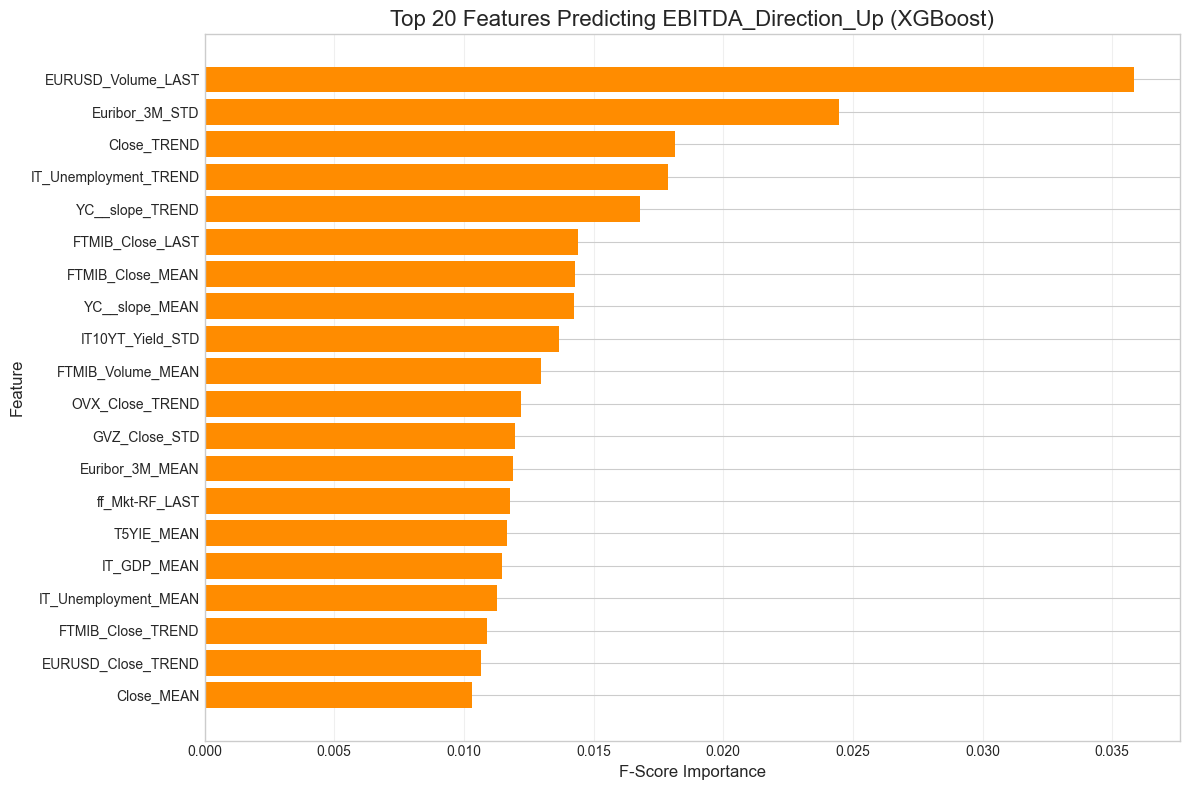

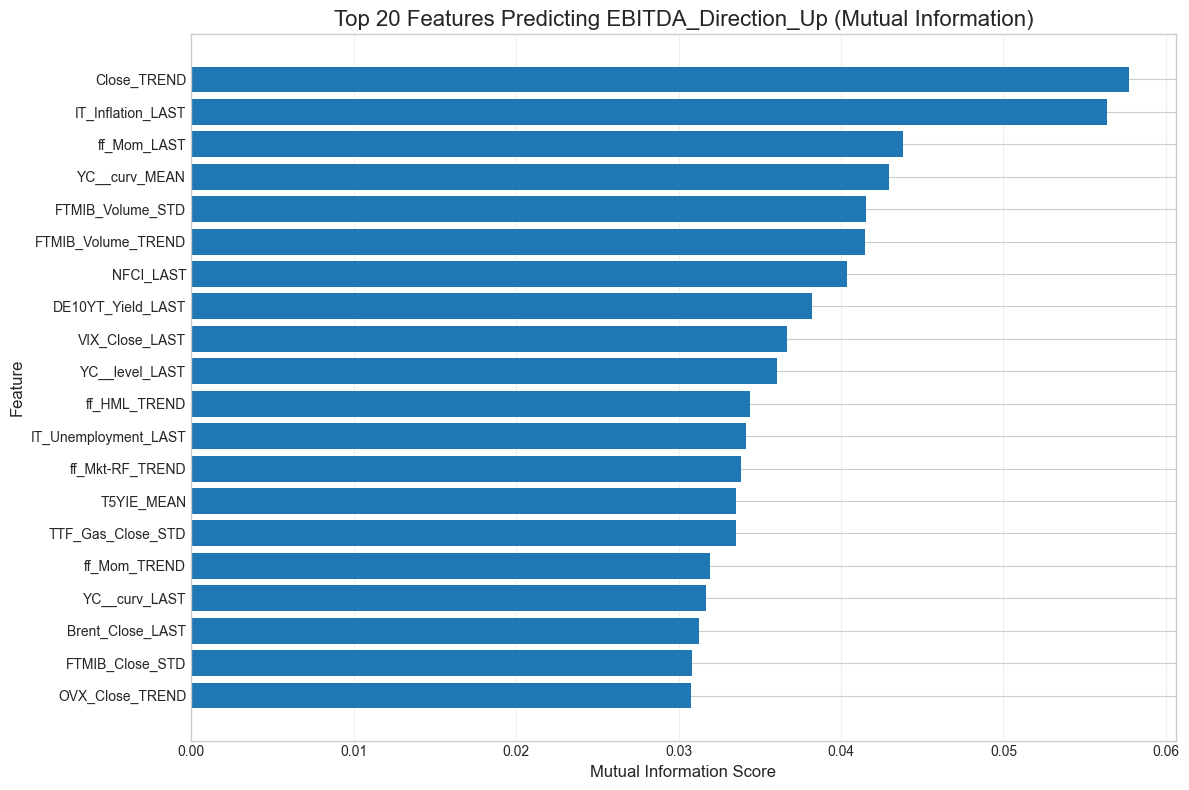

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/3542906977.py:166: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_target, X_test_scaled_df, feature_names=X_test.columns, plot_type="dot", show=False)


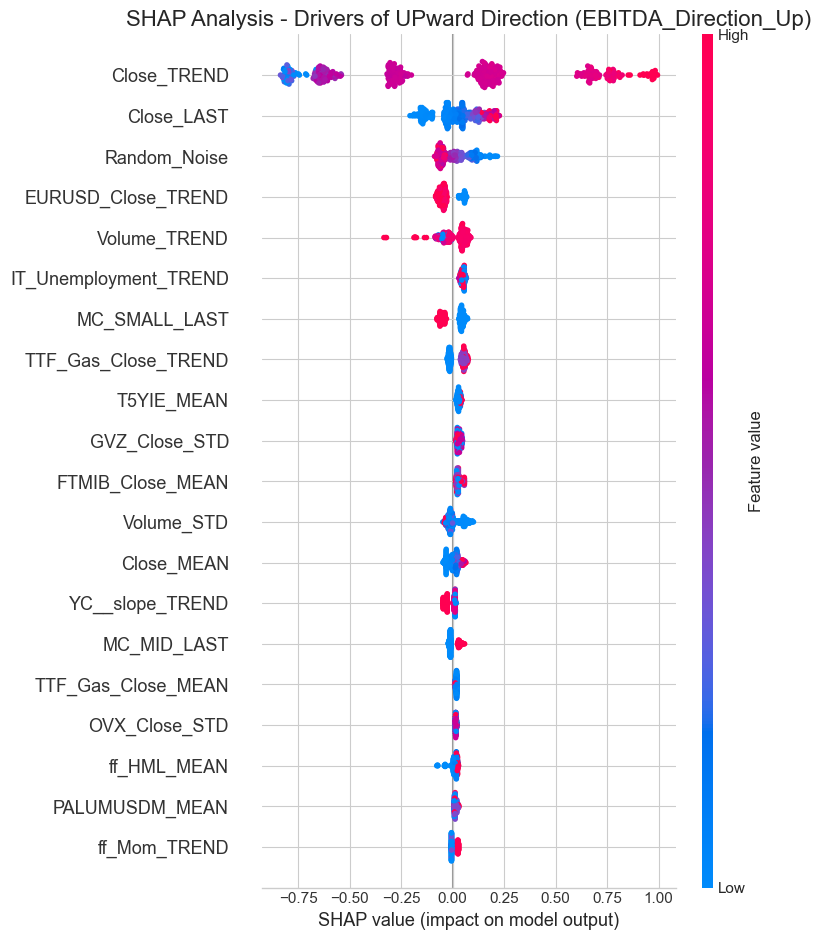


                           ROA_Direction_Up                           
Total valid 365-day windows extracted for classification: 2164

Top 10 features by Mutual Information:
           Feature  MI_Classif
  IT_Inflation_STD    0.064302
   Euribor_3M_LAST    0.055989
   Euribor_3M_MEAN    0.054354
 Brent_Close_TREND    0.049802
    PCOPPUSDM_MEAN    0.045331
   Gold_Close_MEAN    0.042567
      ff_Mom_TREND    0.041559
 EURUSD_Volume_STD    0.041254
TTF_Gas_Close_MEAN    0.040875
  Euribor_3M_TREND    0.040374
Fitting 4 folds for each of 35 candidates, totalling 140 fits
Best XGB Params for ROA_Direction_Up: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 5, 'colsample_bytree': 1.0}

--- Test Set Performance ---
Accuracy: 0.6028
ROC-AUC:  0.6480

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.56      0.57       203
           1       0.62      0.64      0.63       230

    accuracy    

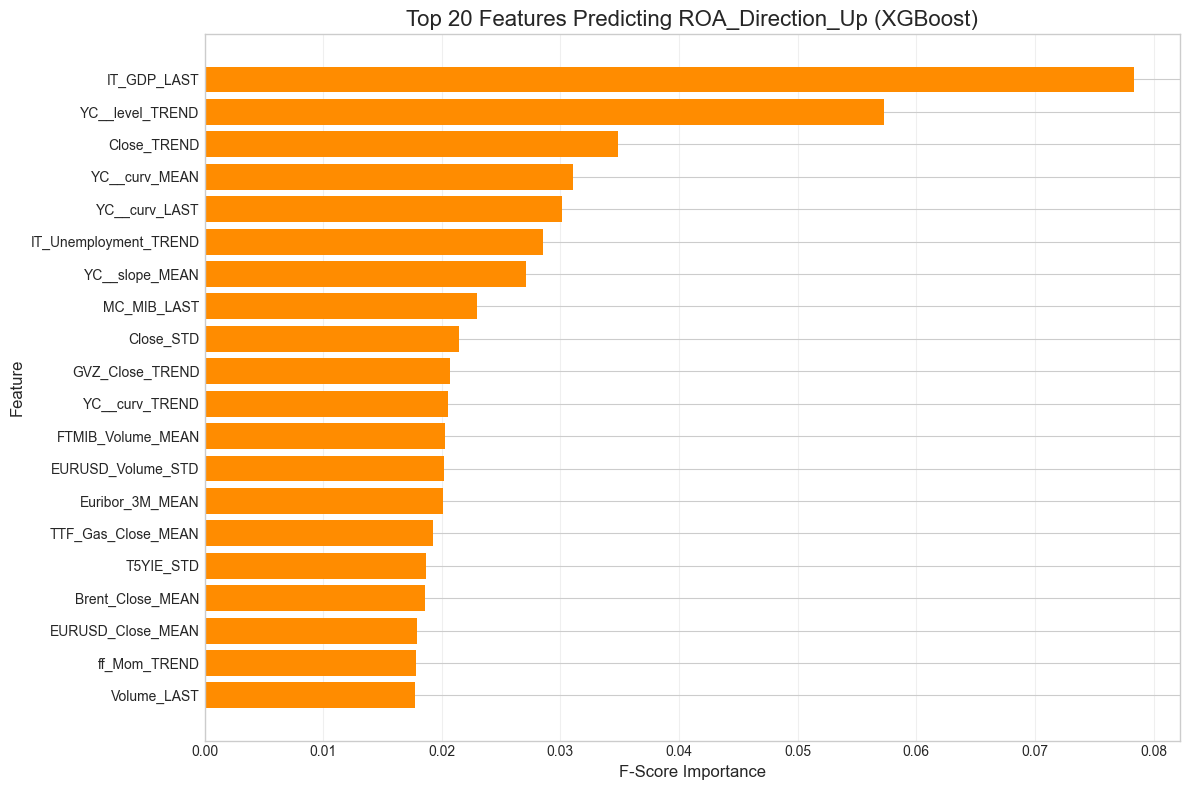

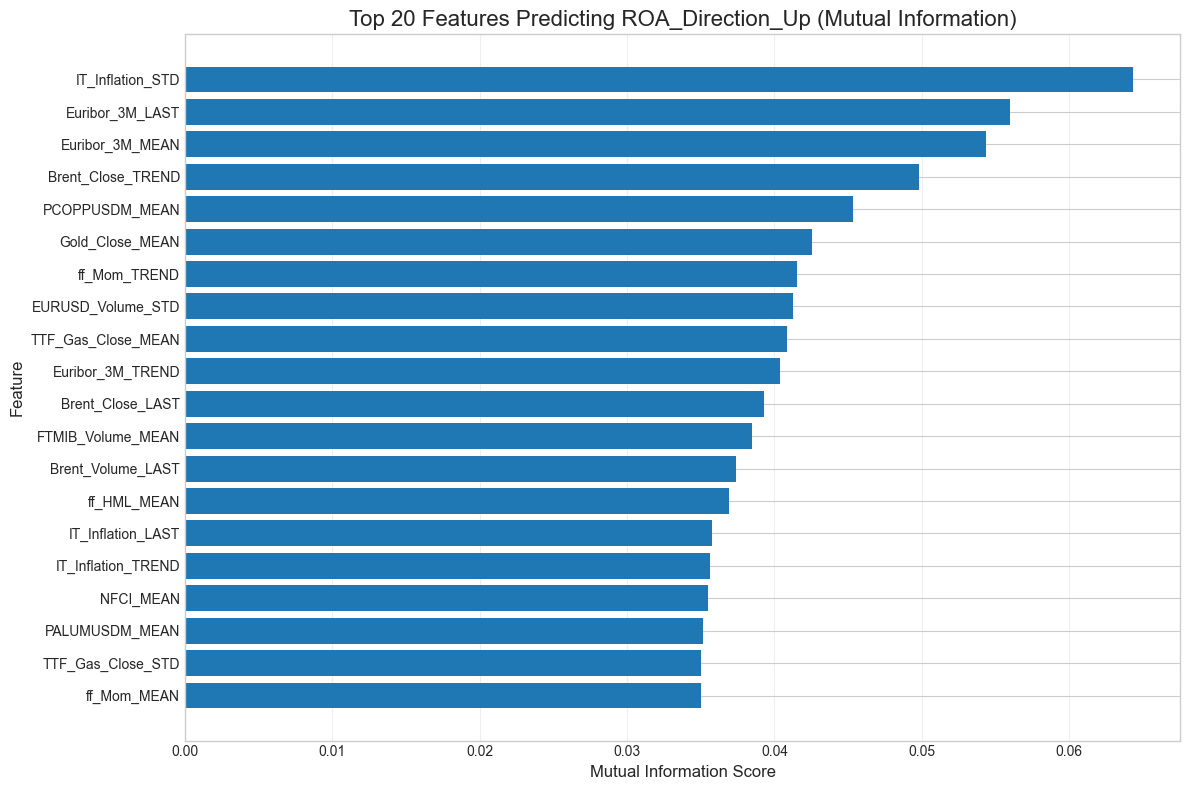

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/3542906977.py:166: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_target, X_test_scaled_df, feature_names=X_test.columns, plot_type="dot", show=False)


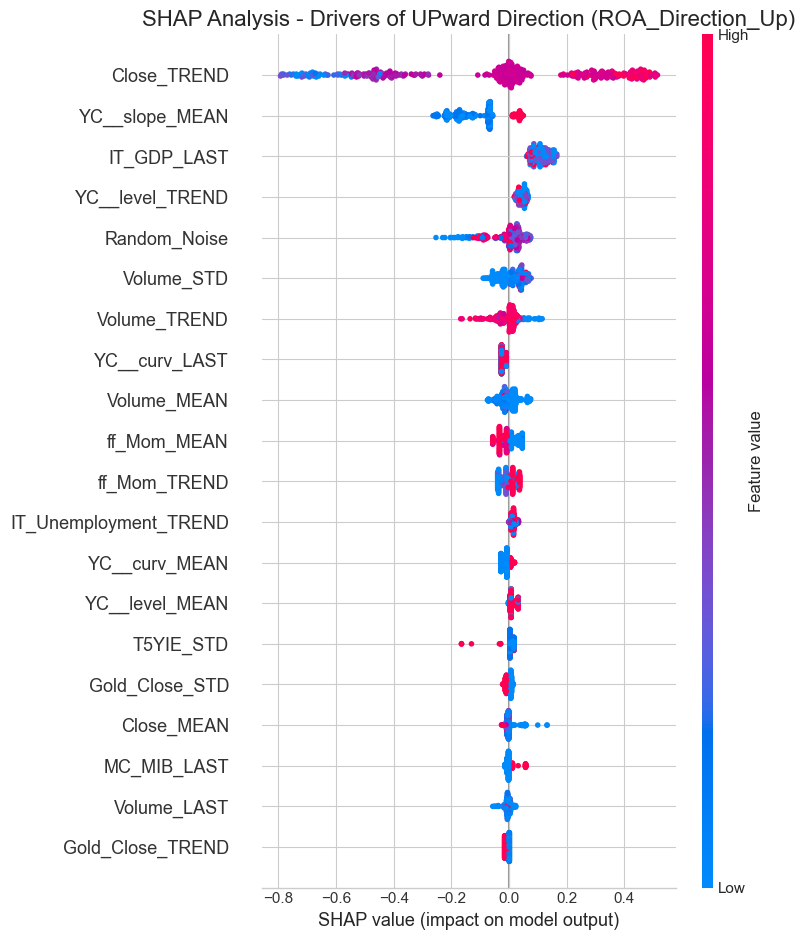


                       Net_Income_Direction_Up                        
Total valid 365-day windows extracted for classification: 2166

Top 10 features by Mutual Information:
         Feature  MI_Classif
Brent_Close_LAST    0.048341
    ff_HML_TREND    0.046160
   YC__slope_STD    0.043945
 VIX_Close_TREND    0.042776
 GVZ_Close_TREND    0.041279
 PALUMUSDM_TREND    0.040379
EURUSD_Close_STD    0.040292
  OVX_Close_LAST    0.040250
DE10YT_Yield_STD    0.039838
   VIX_Close_STD    0.039326
Fitting 4 folds for each of 35 candidates, totalling 140 fits
Best XGB Params for Net_Income_Direction_Up: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 5, 'colsample_bytree': 1.0}

--- Test Set Performance ---
Accuracy: 0.5668
ROC-AUC:  0.6172

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.69      0.56       178
           1       0.69      0.48      0.57       256

    accuracy                   

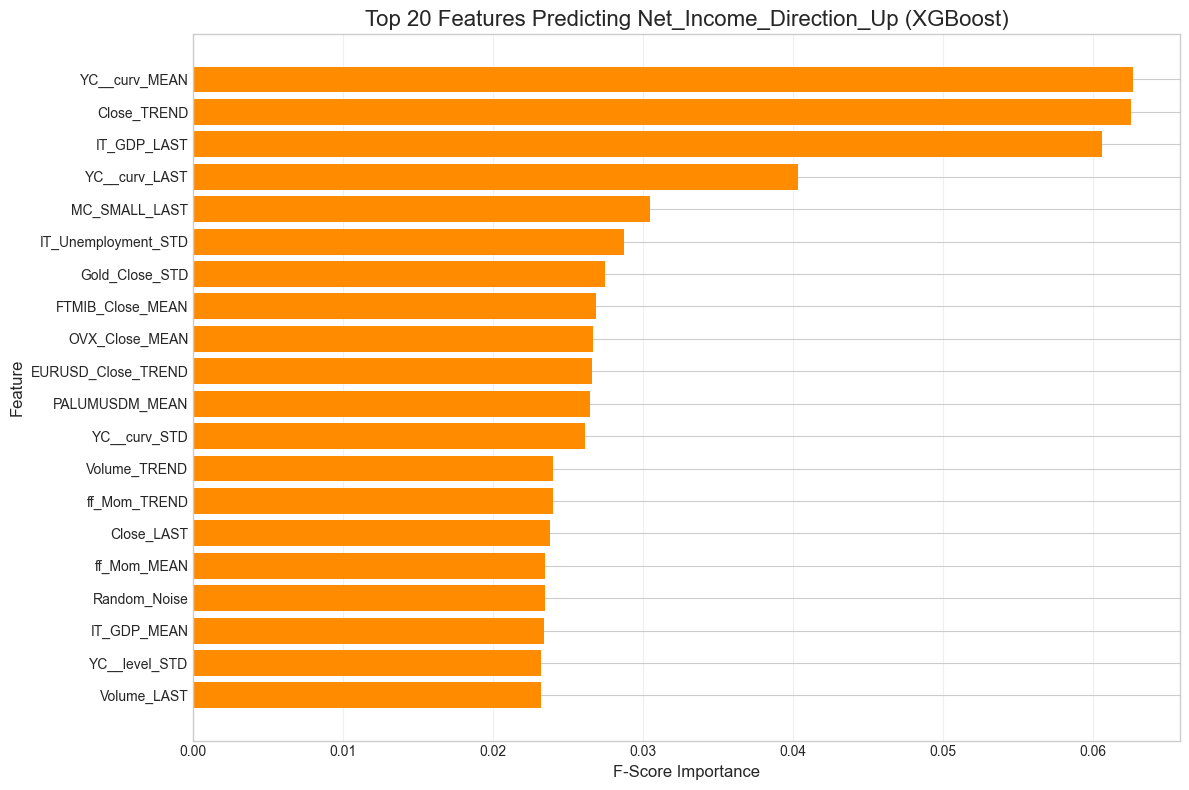

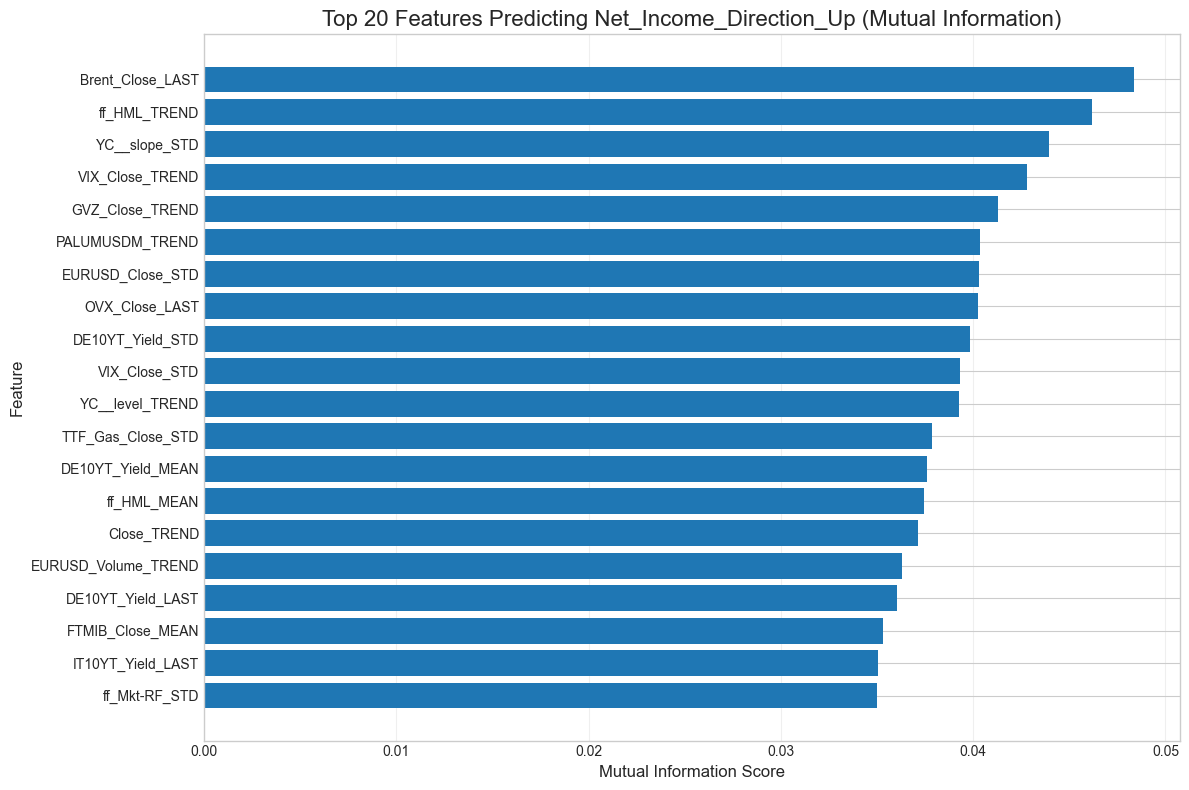

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_40592/3542906977.py:166: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_target, X_test_scaled_df, feature_names=X_test.columns, plot_type="dot", show=False)


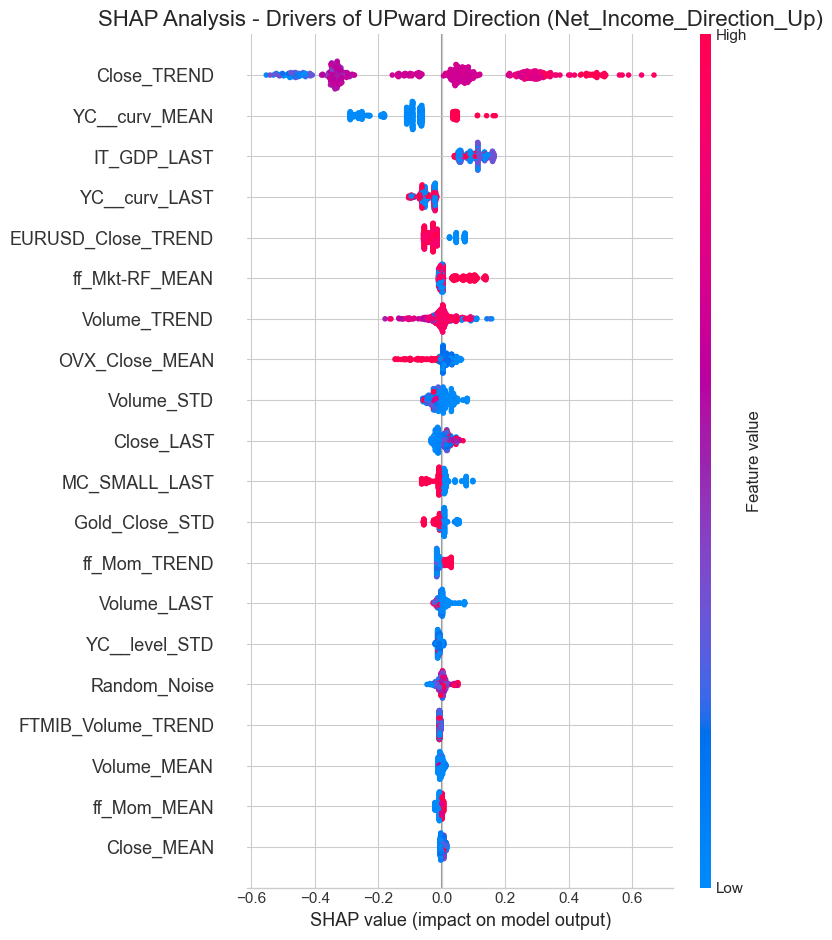


Final Test Performance Summary (XGBoost Classification Models)
                 Target  Test_Accuracy  Test_ROC_AUC
    EBITDA_Direction_Up       0.640845      0.686416
       ROA_Direction_Up       0.602771      0.647997
Net_Income_Direction_Up       0.566820      0.617209


In [55]:
performance_summary = []
df_yoy = df_yoy.sort_values(by=['Company', 'Date']).reset_index(drop=True)

directional_targets = []

for target in targets:
    dir_col = f"{target}_Direction_Up"
    directional_targets.append(dir_col)

    valid_reports = df_yoy[df_yoy[target].notna()].copy()
    valid_reports[dir_col] = valid_reports.groupby('Company')[target].transform(
        lambda x: np.where(x - x.shift(1) > 0, 1, 0)
    )
    valid_reports.loc[valid_reports.groupby('Company')[target].shift(1).isna(), dir_col] = np.nan
    df_yoy[dir_col] = valid_reports[dir_col]

df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in directional_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]
            
            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]
            
            if len(window) > 200:
                window_stats = {'Target_Date': target_date, 'Random_Noise': float(np.random.normal(0, 1))}
                for feat in features:
                    series = window[feat].dropna()
                    if series.empty:
                        if feat in categorical_features:
                            window_stats[f"{feat}_LAST"] = np.nan
                        else:
                            window_stats[f"{feat}_MEAN"] = np.nan
                            window_stats[f"{feat}_STD"] = np.nan
                            window_stats[f"{feat}_LAST"] = np.nan
                            window_stats[f"{feat}_TREND"] = np.nan
                    else:
                        values = series.values.astype(float)
                        if feat in categorical_features:
                            window_stats[f"{feat}_LAST"] = float(values[-1])
                        else:
                            window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                            window_stats[f"{feat}_STD"] = float(np.std(values, ddof=1))
                            window_stats[f"{feat}_LAST"] = float(values[-1])
                            
                            if len(values) > 1:
                                x_axis = np.arange(len(values), dtype=float)
                                slope = np.polyfit(x_axis, values, deg=1)[0]
                            else:
                                slope = np.nan
                            window_stats[f"{feat}_TREND"] = float(slope)

                X_aggregated.append(window_stats)
                y_values.append(int(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    
    print(f"Total valid 365-day windows extracted for classification: {len(X_df)}")
    if len(X_df) < 50:
        print("Not enough samples. Skipping.")
        continue

    # Time-based split to prevent leakage
    X_df['Target_Date'] = pd.to_datetime(X_df['Target_Date'])
    sort_idx = X_df.sort_values('Target_Date').index
    X_df = X_df.loc[sort_idx].reset_index(drop=True)
    y_series = y_series.loc[sort_idx].reset_index(drop=True)
    X_df = X_df.drop(columns=['Target_Date'])

    split_idx = int(len(X_df) * 0.8)
    X_train, X_test = X_df.iloc[:split_idx], X_df.iloc[split_idx:]
    y_train, y_test = y_series.iloc[:split_idx], y_series.iloc[split_idx:]
    
    # Impute missing values with median (fit on train only to prevent leakage)
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='classification')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    xgb_model, best_params = fit_xgb_classifier(X_train_scaled, y_train)
    print(f"Best XGB Params for {target}: {best_params}")
    
    y_pred = xgb_model.predict(X_test_scaled)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n--- Test Set Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    performance_summary.append({
        'Target': target,
        'Best_Params': str(best_params),
        'Test_Accuracy': accuracy,
        'Test_ROC_AUC': roc_auc
    })

    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='darkorange')
    plt.title(f'Top 20 Features Predicting {target} (XGBoost)', fontsize=16)
    plt.xlabel('F-Score Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Mutual Information Plot
    top_mi = mi_df.head(20).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 8))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 20 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Impact Plot
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_values, list):
        shap_values_target = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_target = shap_values[:, :, 1]
    else:
        shap_values_target = shap_values
        
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Analysis - Drivers of UPward Direction ({target})", fontsize=16)
    shap.summary_plot(shap_values_target, X_test_scaled_df, feature_names=X_test.columns, plot_type="dot", show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (XGBoost Classification Models)")
print("=" * 70)
print(performance_summary_df[['Target', 'Test_Accuracy', 'Test_ROC_AUC']].to_string(index=False))